Ctrl + F를 눌러 여기부터를 검색하세요!
전처리하고 번역한 작업내역이라 여기서 실행시키면 안 됩니다!!

In [1]:
from google.cloud import translate

c:\Users\user\.conda\envs\gemini_env\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\user\.conda\envs\gemini_env\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.translate_v3 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.translate_v3 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
import google.cloud
print(dir(google.cloud))

['__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'location', 'translate', 'translate_v3']


In [ ]:
"""

gcloud config set project project-7431ea83-d945-4b5a-9c4
gcloud auth application-default set-quota-project project-7431ea83-d945-4b5a-9c4
"C:\Users\user\AppData\Local\Google\Cloud SDK\google-cloud-sdk\bin\gcloud.cmd" auth application-default set-quota-project project-7431ea83-d945-4b5a-9c4

"""

In [3]:
client = translate.TranslationServiceClient()

project_id = "project-7431ea83-d945-4b5a-9c4"
location = "global"

parent = f"projects/{project_id}/locations/{location}"

response = client.translate_text(
    contents=["Hello! My name is kimsongmi."],
    target_language_code="ko",
    parent=parent,
)

for translation in response.translations:
    print(translation.translated_text)

안녕하세요! 제 이름은 김송미입니다.


In [4]:
pip install langdetect

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install emoji

In [3]:
import pandas as pd
import re
import emoji
from langdetect import detect

In [130]:
# 파일 경로

'''
comments_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\ADCMains\comments_ADCMains.csv"
posts_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\ADCMains\posts_ADCMains.csv"

save_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\ADCMains\Data_ADCMains.csv"
'''

comments_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\top_mains\comments_top_mains.csv"
posts_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\top_mains\posts_top_mains.csv"

save_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\top_mains\Data_top_mains.csv"



In [131]:
# 파일 읽기
comments = pd.read_csv(comments_path)
posts = pd.read_csv(posts_path)

In [132]:
# 날짜 변환
comments["comment_created_dt"] = pd.to_datetime(comments["comment_created_utc"], unit="s", errors="coerce")

posts["post_created_dt"] = pd.to_datetime(posts["created_utc"], unit="s", errors="coerce")

In [133]:
# deleted / removed 제거
comments = comments[~comments["comment_body"].isin(["[deleted]", "[removed]"])]

In [134]:
# bot 제거
comments = comments[~comments["comment_author"].str.contains("bot", case=False, na=False)]

In [135]:
# 중복 제거
comments = comments.drop_duplicates(subset=["comment_id"])

In [136]:
# 필요한 칼럼만 추출 후 이름 변경해주고 병합
posts = posts[["subreddit","id","title","post_created_dt","score","num_comments"
            ]].rename(columns={"id": "post_id","title": "post_title","score": "post_score","num_comments": "post_num_comments"})

comments = comments[["post_id","comment_id","comment_author","comment_score","comment_created_dt","comment_body"
            ]].rename(columns={"comment_body": "comment_body_raw"})

df = pd.merge(comments, posts, on="post_id", how="left")

In [137]:
df

,post_id,comment_id,comment_author,comment_score,comment_created_dt,comment_body_raw,subreddit,post_title,post_created_dt,post_score,post_num_comments
0,1pgj84n,nsrhoaf,mozes05,67,2025-12-07 14:13:04,Forgot one\n\nhttps://i.redd.it/3mdzzvpwb2t81.jpg,top_mains,Just saw that and had to share it,2025-12-07 14:09:41,3713,97
1,1pgj84n,nsrpome,Totoques22,64,2025-12-07 14:59:24,Unfortunately the scorpion 🦂 has not been good...,top_mains,Just saw that and had to share it,2025-12-07 14:09:41,3713,97
2,1pgj84n,nsrwqcw,MifiBox,22,2025-12-07 15:37:54,When the demonic catfish gets reduced to a fro...,top_mains,Just saw that and had to share it,2025-12-07 14:09:41,3713,97
3,1pgj84n,nssovx4,fozzy_fosbourne,17,2025-12-07 18:01:58,Jungle was all little weird freaks until the a...,top_mains,Just saw that and had to share it,2025-12-07 14:09:41,3713,97
4,1pgj84n,nsrs3po,SpectatorBeholder,7,2025-12-07 15:12:56,Actually he's a catfish,top_mains,Just saw that and had to share it,2025-12-07 14:09:41,3713,97
...,...,...,...,...,...,...,...,...,...,...,...
10039,1ogc8ju,nlfvy8a,The_God_of_Biscuits,0,2025-10-26 07:18:25,"If you have prio, you can crash whenever if jg...",top_mains,How do I stop accidentally giving freeze every...,2025-10-26 05:09:24,8,11
10040,1pc5che,nrv6swj,Desperate-Zebra-3855,15,2025-12-02 10:51:24,"As an example, Aatrox gets roughly 5 ad per le...",top_mains,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6
10041,1pc5che,nrw4lvq,Active-Advisor5909,3,2025-12-02 14:45:32,Steraks will be slightly better. But a bonus 6...,top_mains,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6
10042,1pc5che,nsg25jd,Mindless-Humor-9036,1,2025-12-05 16:21:43,I think you’re over thinking it tbh. I only go...,top_mains,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6


In [138]:
# 이모지 추출
def extract_emojis(text):
    return [c for c in text if c in emoji.EMOJI_DATA]

df["emoji_list"] = df["comment_body_raw"].apply(
    lambda x: extract_emojis(str(x))
)

df["emoji_count"] = df["emoji_list"].apply(len)

In [139]:
# 텍스트 정리
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # URL 제거
    text = re.sub(r"\b\d{1,2}:\d{2}\b", "", text)  # timestamp 제거
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", "", text)  # 특수문자 제거
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["comment_body_clean"] = df["comment_body_raw"].apply(clean_text)

In [140]:
df

,post_id,comment_id,comment_author,comment_score,comment_created_dt,comment_body_raw,subreddit,post_title,post_created_dt,post_score,post_num_comments,emoji_list,emoji_count,comment_body_clean
0,1pgj84n,nsrhoaf,mozes05,67,2025-12-07 14:13:04,Forgot one\n\nhttps://i.redd.it/3mdzzvpwb2t81.jpg,top_mains,Just saw that and had to share it,2025-12-07 14:09:41,3713,97,[],0,forgot one
1,1pgj84n,nsrpome,Totoques22,64,2025-12-07 14:59:24,Unfortunately the scorpion 🦂 has not been good...,top_mains,Just saw that and had to share it,2025-12-07 14:09:41,3713,97,"[🦂, 🐸, 🐏, 🔥, 🪓, 🧟]",6,unfortunately the scorpion has not been good i...
2,1pgj84n,nsrwqcw,MifiBox,22,2025-12-07 15:37:54,When the demonic catfish gets reduced to a fro...,top_mains,Just saw that and had to share it,2025-12-07 14:09:41,3713,97,"[🥀, 🥀]",2,when the demonic catfish gets reduced to a frog
3,1pgj84n,nssovx4,fozzy_fosbourne,17,2025-12-07 18:01:58,Jungle was all little weird freaks until the a...,top_mains,Just saw that and had to share it,2025-12-07 14:09:41,3713,97,[],0,jungle was all little weird freaks until the a...
4,1pgj84n,nsrs3po,SpectatorBeholder,7,2025-12-07 15:12:56,Actually he's a catfish,top_mains,Just saw that and had to share it,2025-12-07 14:09:41,3713,97,[],0,actually hes a catfish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10039,1ogc8ju,nlfvy8a,The_God_of_Biscuits,0,2025-10-26 07:18:25,"If you have prio, you can crash whenever if jg...",top_mains,How do I stop accidentally giving freeze every...,2025-10-26 05:09:24,8,11,[],0,if you have prio you can crash whenever if jg ...
10040,1pc5che,nrv6swj,Desperate-Zebra-3855,15,2025-12-02 10:51:24,"As an example, Aatrox gets roughly 5 ad per le...",top_mains,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,[],0,as an example aatrox gets roughly 5 ad per lev...
10041,1pc5che,nrw4lvq,Active-Advisor5909,3,2025-12-02 14:45:32,Steraks will be slightly better. But a bonus 6...,top_mains,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,[],0,steraks will be slightly better but a bonus 6 ...
10042,1pc5che,nsg25jd,Mindless-Humor-9036,1,2025-12-05 16:21:43,I think you’re over thinking it tbh. I only go...,top_mains,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,[],0,i think youre over thinking it tbh i only go s...


In [141]:
# 언어 감지 (조금 걸림!! 느림)
def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

df["language"] = df["comment_body_clean"].apply(detect_lang)

In [142]:
# 컬럼 정렬
df = df[[
    "subreddit",
    "post_id",
    "post_title",
    "post_created_dt",
    "post_score",
    "post_num_comments",
    "comment_id",
    "comment_author",
    "comment_score",
    "comment_created_dt",
    "comment_body_raw",
    "comment_body_clean",
    "emoji_list",
    "emoji_count",
    "language"
]]

In [143]:
df

,subreddit,post_id,post_title,post_created_dt,post_score,post_num_comments,comment_id,comment_author,comment_score,comment_created_dt,comment_body_raw,comment_body_clean,emoji_list,emoji_count,language
0,top_mains,1pgj84n,Just saw that and had to share it,2025-12-07 14:09:41,3713,97,nsrhoaf,mozes05,67,2025-12-07 14:13:04,Forgot one\n\nhttps://i.redd.it/3mdzzvpwb2t81.jpg,forgot one,[],0,en
1,top_mains,1pgj84n,Just saw that and had to share it,2025-12-07 14:09:41,3713,97,nsrpome,Totoques22,64,2025-12-07 14:59:24,Unfortunately the scorpion 🦂 has not been good...,unfortunately the scorpion has not been good i...,"[🦂, 🐸, 🐏, 🔥, 🪓, 🧟]",6,en
2,top_mains,1pgj84n,Just saw that and had to share it,2025-12-07 14:09:41,3713,97,nsrwqcw,MifiBox,22,2025-12-07 15:37:54,When the demonic catfish gets reduced to a fro...,when the demonic catfish gets reduced to a frog,"[🥀, 🥀]",2,en
3,top_mains,1pgj84n,Just saw that and had to share it,2025-12-07 14:09:41,3713,97,nssovx4,fozzy_fosbourne,17,2025-12-07 18:01:58,Jungle was all little weird freaks until the a...,jungle was all little weird freaks until the a...,[],0,en
4,top_mains,1pgj84n,Just saw that and had to share it,2025-12-07 14:09:41,3713,97,nsrs3po,SpectatorBeholder,7,2025-12-07 15:12:56,Actually he's a catfish,actually hes a catfish,[],0,en
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10039,top_mains,1ogc8ju,How do I stop accidentally giving freeze every...,2025-10-26 05:09:24,8,11,nlfvy8a,The_God_of_Biscuits,0,2025-10-26 07:18:25,"If you have prio, you can crash whenever if jg...",if you have prio you can crash whenever if jg ...,[],0,en
10040,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrv6swj,Desperate-Zebra-3855,15,2025-12-02 10:51:24,"As an example, Aatrox gets roughly 5 ad per le...",as an example aatrox gets roughly 5 ad per lev...,[],0,en
10041,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrw4lvq,Active-Advisor5909,3,2025-12-02 14:45:32,Steraks will be slightly better. But a bonus 6...,steraks will be slightly better but a bonus 6 ...,[],0,en
10042,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nsg25jd,Mindless-Humor-9036,1,2025-12-05 16:21:43,I think you’re over thinking it tbh. I only go...,i think youre over thinking it tbh i only go s...,[],0,en


In [ ]:
# 저장
df.to_csv(save_path, index=False, encoding="utf-8-sig")

print("저장 완료")

저장 완료


In [ ]:
'''
Data_ADBMains.csv
Data_Jungle_Mains.csv
Data_leagueoflegends.csv
Data_LeagueOfMemes.csv
Data_midlanemains.csv
Data_summonerschool.csv
Data_supportlol.csv
Data_top_mains.csv
'''

In [5]:
file_paths = [
    r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\ADCMains\Data_ADCMains.csv",
    r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\Jungle_Mains\Data_Jungle_Mains.csv",
    r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\leagueoflegends\Data_leagueoflegends.csv",
    r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\LeagueOfMemes\Data_LeagueOfMemes.csv",
    r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\midlanemains\Data_midlanemains.csv",
    r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\summonerschool\Data_summonerschool.csv",
    r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\supportlol\Data_supportlol.csv",
    r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\top_mains\Data_top_mains.csv"
]

In [56]:
# 파일 불러오기
df_list = []

for path in file_paths:
    temp = pd.read_csv(path)
    print(f"{path} -> {len(temp)} rows")
    df_list.append(temp)

F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\ADCMains\Data_ADCMains.csv -> 15725 rows
F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\Jungle_Mains\Data_Jungle_Mains.csv -> 16394 rows
F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\leagueoflegends\Data_leagueoflegends.csv -> 44936 rows
F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\LeagueOfMemes\Data_LeagueOfMemes.csv -> 15209 rows
F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\midlanemains\Data_midlanemains.csv -> 6049 rows
F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\summonerschool\Data_summonerschool.csv -> 12381 rows
F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\supportlol\Data_supportlol.csv -> 13931 rows
F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\top_mains\Data_top_mains.csv -> 10044 rows


In [57]:
# 병합
df = pd.concat(df_list, ignore_index=True)

print("\n병합 완료")
print("총 행 수:", len(df))
df


병합 완료
총 행 수: 134669


,subreddit,post_id,post_title,post_created_dt,post_score,post_num_comments,comment_id,comment_author,comment_score,comment_created_dt,comment_body_raw,comment_body_clean,emoji_list,emoji_count,language
0,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta7jrv,lahartheviking,240,2025-12-10 13:06:48,if enemy adc is one item before me i run down mid,if enemy adc is one item before me i run down mid,[],0,en
1,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0cvt,Icy-Hour-5031,232,2025-12-10 12:16:21,There are a lot of adcs that if they are behin...,there are a lot of adcs that if they are behin...,[],0,en
2,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntacod6,theeama,152,2025-12-10 13:38:37,Jinx ain't the champion to use here because if...,jinx aint the champion to use here because if ...,[],0,en
3,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0es1,Low_Direction1774,92,2025-12-10 12:16:45,"Youre not an ADC main, are you?",youre not an adc main are you,[],0,en
4,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntammgw,Babushla153,37,2025-12-10 14:36:06,At that point if you die as 8/0 dairus against...,at that point if you die as 80 dairus against ...,[],0,en
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134664,top_mains,1ogc8ju,How do I stop accidentally giving freeze every...,2025-10-26 05:09:24,8,11,nlfvy8a,The_God_of_Biscuits,0,2025-10-26 07:18:25,"If you have prio, you can crash whenever if jg...",if you have prio you can crash whenever if jg ...,[],0,en
134665,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrv6swj,Desperate-Zebra-3855,15,2025-12-02 10:51:24,"As an example, Aatrox gets roughly 5 ad per le...",as an example aatrox gets roughly 5 ad per lev...,[],0,en
134666,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrw4lvq,Active-Advisor5909,3,2025-12-02 14:45:32,Steraks will be slightly better. But a bonus 6...,steraks will be slightly better but a bonus 6 ...,[],0,en
134667,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nsg25jd,Mindless-Humor-9036,1,2025-12-05 16:21:43,I think you’re over thinking it tbh. I only go...,i think youre over thinking it tbh i only go s...,[],0,en


In [58]:
# 병합 후 확인차 중복 제거 재확인
if "comment_id" in df.columns:
    before = len(df)
    df = df.drop_duplicates(subset=["comment_id"])
    after = len(df)
    print(f"중복 제거: {before - after} rows 삭제됨")

중복 제거: 0 rows 삭제됨


In [59]:
# has_emoji : 이모티콘이 있냐없냐 true/false 칼럼 추가하기

# emoji_count가 이미 있는 경우
if "emoji_count" in df.columns:
    df["has_emoji"] = df["emoji_count"] > 0

# 없는 경우 직접 계산
else:
    def has_emoji(text):
        return any(c in emoji.EMOJI_DATA for c in str(text))

    df["has_emoji"] = df["comment_body_raw"].apply(has_emoji)

print("has_emoji 컬럼 추가 완료")

has_emoji 컬럼 추가 완료


In [60]:
print("\n현재 컬럼 목록:")
print(df.columns)

print("\n결측치 총 개수:", df.isnull().sum().sum())
df


현재 컬럼 목록:
Index(['subreddit', 'post_id', 'post_title', 'post_created_dt', 'post_score',
       'post_num_comments', 'comment_id', 'comment_author', 'comment_score',
       'comment_created_dt', 'comment_body_raw', 'comment_body_clean',
       'emoji_list', 'emoji_count', 'language', 'has_emoji'],
      dtype='object')

결측치 총 개수: 469


,subreddit,post_id,post_title,post_created_dt,post_score,post_num_comments,comment_id,comment_author,comment_score,comment_created_dt,comment_body_raw,comment_body_clean,emoji_list,emoji_count,language,has_emoji
0,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta7jrv,lahartheviking,240,2025-12-10 13:06:48,if enemy adc is one item before me i run down mid,if enemy adc is one item before me i run down mid,[],0,en,False
1,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0cvt,Icy-Hour-5031,232,2025-12-10 12:16:21,There are a lot of adcs that if they are behin...,there are a lot of adcs that if they are behin...,[],0,en,False
2,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntacod6,theeama,152,2025-12-10 13:38:37,Jinx ain't the champion to use here because if...,jinx aint the champion to use here because if ...,[],0,en,False
3,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0es1,Low_Direction1774,92,2025-12-10 12:16:45,"Youre not an ADC main, are you?",youre not an adc main are you,[],0,en,False
4,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntammgw,Babushla153,37,2025-12-10 14:36:06,At that point if you die as 8/0 dairus against...,at that point if you die as 80 dairus against ...,[],0,en,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134664,top_mains,1ogc8ju,How do I stop accidentally giving freeze every...,2025-10-26 05:09:24,8,11,nlfvy8a,The_God_of_Biscuits,0,2025-10-26 07:18:25,"If you have prio, you can crash whenever if jg...",if you have prio you can crash whenever if jg ...,[],0,en,False
134665,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrv6swj,Desperate-Zebra-3855,15,2025-12-02 10:51:24,"As an example, Aatrox gets roughly 5 ad per le...",as an example aatrox gets roughly 5 ad per lev...,[],0,en,False
134666,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrw4lvq,Active-Advisor5909,3,2025-12-02 14:45:32,Steraks will be slightly better. But a bonus 6...,steraks will be slightly better but a bonus 6 ...,[],0,en,False
134667,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nsg25jd,Mindless-Humor-9036,1,2025-12-05 16:21:43,I think you’re over thinking it tbh. I only go...,i think youre over thinking it tbh i only go s...,[],0,en,False


In [61]:
before = len(df)

df = df[~df["comment_body_raw"].str.contains("http", na=False)]

after = len(df)

print("URL 포함 행 제거:", before - after)
print("남은 행 수:", after)

URL 포함 행 제거: 2110
남은 행 수: 132559


In [62]:
# 결측치 제거 (comment_body_clean, comment_id)
# comment_body_clean이 NaN이거나 공백인 것 제거
before = len(df)

df = df[df["comment_body_clean"].fillna("").str.strip() != ""]

after = len(df)
print("\n1. 빈 댓글 제거")
print("제거된 행 수:", before - after)
print("남은 행 수:", after)


1. 빈 댓글 제거
제거된 행 수: 81
남은 행 수: 132478


In [63]:
# comment_id가 없는 행 제거
before = len(df)

df = df[df["comment_id"].notna()]

after = len(df)
print("\n2. comment_id 결측 제거")
print("제거된 행 수:", before - after)
print("남은 행 수:", after)



2. comment_id 결측 제거
제거된 행 수: 0
남은 행 수: 132478


In [64]:
# 결측치 재확인
print("총 행 수:", len(df))
print("\n=== 결측치 개수 ===")
print(df.isnull().sum())

총 행 수: 132478

=== 결측치 개수 ===
subreddit             0
post_id               0
post_title            0
post_created_dt       0
post_score            0
post_num_comments     0
comment_id            0
comment_author        0
comment_score         0
comment_created_dt    0
comment_body_raw      1
comment_body_clean    0
emoji_list            0
emoji_count           0
language              0
has_emoji             0
dtype: int64


In [65]:
import re

def clean_text_strict(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # 소문자 변환
    text = text.lower()

    # 줄바꿈만 정리
    text = text.replace("\n", " ").replace("\r", " ")
    
    # 공백 여러 개 → 하나
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

df["comment_body_clean"] = df["comment_body_raw"].apply(clean_text_strict)

print("comment_body_clean 재생성 완료")

comment_body_clean 재생성 완료


In [66]:
df

,subreddit,post_id,post_title,post_created_dt,post_score,post_num_comments,comment_id,comment_author,comment_score,comment_created_dt,comment_body_raw,comment_body_clean,emoji_list,emoji_count,language,has_emoji
0,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta7jrv,lahartheviking,240,2025-12-10 13:06:48,if enemy adc is one item before me i run down mid,if enemy adc is one item before me i run down mid,[],0,en,False
1,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0cvt,Icy-Hour-5031,232,2025-12-10 12:16:21,There are a lot of adcs that if they are behin...,there are a lot of adcs that if they are behin...,[],0,en,False
2,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntacod6,theeama,152,2025-12-10 13:38:37,Jinx ain't the champion to use here because if...,jinx ain't the champion to use here because if...,[],0,en,False
3,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0es1,Low_Direction1774,92,2025-12-10 12:16:45,"Youre not an ADC main, are you?","youre not an adc main, are you?",[],0,en,False
4,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntammgw,Babushla153,37,2025-12-10 14:36:06,At that point if you die as 8/0 dairus against...,at that point if you die as 8/0 dairus against...,[],0,en,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134664,top_mains,1ogc8ju,How do I stop accidentally giving freeze every...,2025-10-26 05:09:24,8,11,nlfvy8a,The_God_of_Biscuits,0,2025-10-26 07:18:25,"If you have prio, you can crash whenever if jg...","if you have prio, you can crash whenever if jg...",[],0,en,False
134665,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrv6swj,Desperate-Zebra-3855,15,2025-12-02 10:51:24,"As an example, Aatrox gets roughly 5 ad per le...","as an example, aatrox gets roughly 5 ad per le...",[],0,en,False
134666,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrw4lvq,Active-Advisor5909,3,2025-12-02 14:45:32,Steraks will be slightly better. But a bonus 6...,steraks will be slightly better. but a bonus 6...,[],0,en,False
134667,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nsg25jd,Mindless-Humor-9036,1,2025-12-05 16:21:43,I think you’re over thinking it tbh. I only go...,i think you’re over thinking it tbh. i only go...,[],0,en,False


In [ ]:
# 전처리 파일 최종 저장
save_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\Reddit_Master_Data.csv"

df.to_csv(save_path, index=False, encoding="utf-8-sig")

print("\n저장 완료")
print("저장 경로:", save_path)
print("최종 행 수:", len(df))


저장 완료
저장 경로: F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\data\Reddit\Reddit_Master_Data.csv
최종 행 수: 132478


In [67]:
# 번역 잘못될까봐 복사하여 사용
df_2 = df.copy()

In [68]:
df_2

,subreddit,post_id,post_title,post_created_dt,post_score,post_num_comments,comment_id,comment_author,comment_score,comment_created_dt,comment_body_raw,comment_body_clean,emoji_list,emoji_count,language,has_emoji
0,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta7jrv,lahartheviking,240,2025-12-10 13:06:48,if enemy adc is one item before me i run down mid,if enemy adc is one item before me i run down mid,[],0,en,False
1,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0cvt,Icy-Hour-5031,232,2025-12-10 12:16:21,There are a lot of adcs that if they are behin...,there are a lot of adcs that if they are behin...,[],0,en,False
2,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntacod6,theeama,152,2025-12-10 13:38:37,Jinx ain't the champion to use here because if...,jinx ain't the champion to use here because if...,[],0,en,False
3,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0es1,Low_Direction1774,92,2025-12-10 12:16:45,"Youre not an ADC main, are you?","youre not an adc main, are you?",[],0,en,False
4,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntammgw,Babushla153,37,2025-12-10 14:36:06,At that point if you die as 8/0 dairus against...,at that point if you die as 8/0 dairus against...,[],0,en,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134664,top_mains,1ogc8ju,How do I stop accidentally giving freeze every...,2025-10-26 05:09:24,8,11,nlfvy8a,The_God_of_Biscuits,0,2025-10-26 07:18:25,"If you have prio, you can crash whenever if jg...","if you have prio, you can crash whenever if jg...",[],0,en,False
134665,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrv6swj,Desperate-Zebra-3855,15,2025-12-02 10:51:24,"As an example, Aatrox gets roughly 5 ad per le...","as an example, aatrox gets roughly 5 ad per le...",[],0,en,False
134666,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrw4lvq,Active-Advisor5909,3,2025-12-02 14:45:32,Steraks will be slightly better. But a bonus 6...,steraks will be slightly better. but a bonus 6...,[],0,en,False
134667,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nsg25jd,Mindless-Humor-9036,1,2025-12-05 16:21:43,I think you’re over thinking it tbh. I only go...,i think you’re over thinking it tbh. i only go...,[],0,en,False


In [69]:
df_2 = df_2[df_2["comment_body_clean"].str.contains(r"[a-zA-Z]", na=False)]
df_2

,subreddit,post_id,post_title,post_created_dt,post_score,post_num_comments,comment_id,comment_author,comment_score,comment_created_dt,comment_body_raw,comment_body_clean,emoji_list,emoji_count,language,has_emoji
0,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta7jrv,lahartheviking,240,2025-12-10 13:06:48,if enemy adc is one item before me i run down mid,if enemy adc is one item before me i run down mid,[],0,en,False
1,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0cvt,Icy-Hour-5031,232,2025-12-10 12:16:21,There are a lot of adcs that if they are behin...,there are a lot of adcs that if they are behin...,[],0,en,False
2,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntacod6,theeama,152,2025-12-10 13:38:37,Jinx ain't the champion to use here because if...,jinx ain't the champion to use here because if...,[],0,en,False
3,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0es1,Low_Direction1774,92,2025-12-10 12:16:45,"Youre not an ADC main, are you?","youre not an adc main, are you?",[],0,en,False
4,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntammgw,Babushla153,37,2025-12-10 14:36:06,At that point if you die as 8/0 dairus against...,at that point if you die as 8/0 dairus against...,[],0,en,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134664,top_mains,1ogc8ju,How do I stop accidentally giving freeze every...,2025-10-26 05:09:24,8,11,nlfvy8a,The_God_of_Biscuits,0,2025-10-26 07:18:25,"If you have prio, you can crash whenever if jg...","if you have prio, you can crash whenever if jg...",[],0,en,False
134665,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrv6swj,Desperate-Zebra-3855,15,2025-12-02 10:51:24,"As an example, Aatrox gets roughly 5 ad per le...","as an example, aatrox gets roughly 5 ad per le...",[],0,en,False
134666,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrw4lvq,Active-Advisor5909,3,2025-12-02 14:45:32,Steraks will be slightly better. But a bonus 6...,steraks will be slightly better. but a bonus 6...,[],0,en,False
134667,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nsg25jd,Mindless-Humor-9036,1,2025-12-05 16:21:43,I think you’re over thinking it tbh. I only go...,i think you’re over thinking it tbh. i only go...,[],0,en,False


In [70]:
# 종류별 개수
lang_counts = df["language"].value_counts(dropna=False)

print("\n language 종류별 개수")
print(lang_counts)

print("\n 전체 대비 비율 (%)")
print((lang_counts / len(df) * 100).round(2))


 language 종류별 개수
language
en         117498
cy           1135
af           1071
so           1068
no            880
tl            834
it            810
fr            768
da            742
et            695
fi            657
nl            657
id            515
sv            515
pl            510
ca            456
sw            427
tr            414
ro            397
es            353
pt            308
hr            247
sl            231
sq            227
lt            215
de            185
hu            177
sk            155
lv            140
cs            103
unknown        49
vi             27
ko             12
Name: count, dtype: int64

 전체 대비 비율 (%)
language
en         88.69
cy          0.86
af          0.81
so          0.81
no          0.66
tl          0.63
it          0.61
fr          0.58
da          0.56
et          0.52
fi          0.50
nl          0.50
id          0.39
sv          0.39
pl          0.38
ca          0.34
sw          0.32
tr          0.31
ro          0.30
es    

In [71]:
# 영어만 필터링
df_en = df_2[df_2["language"] == "en"].copy()
print("영어 데이터:", len(df_en))

영어 데이터: 117498


In [72]:
import time
from google.cloud import translate

In [73]:
# 설정
PROJECT_ID = "project-7431ea83-d945-4b5a-9c4"
LOCATION = "global"
OUTPUT_FILE = "translated_progress_gcloud_ver.csv"
BATCH_SIZE = 200  # 100~300 추천

MAX_CODEPOINTS = 28000  # 30720보다 여유 있게

In [74]:
# 클라이언트 생성
client = translate.TranslationServiceClient()
parent = f"projects/{PROJECT_ID}/locations/{LOCATION}"

In [75]:
# 진행 파일 로드
try:
    df_en = pd.read_csv(OUTPUT_FILE)
    print("* 기존 진행 파일 불러옴")
except:
    if "translated_text" not in df_en.columns:
        df_en["translated_text"] = None
    print("새 번역 시작")

to_translate = df_en[df_en["translated_text"].isna()]
total_remaining = len(to_translate)

print(f"* 남은 번역 개수: {total_remaining}")

start_time = time.time()
processed = 0

texts_buffer = []
index_buffer = []
current_length = 0

for idx, row in to_translate.iterrows():
    text = str(row["comment_body_clean"])
    text_len = len(text)

    # 단일 문장이 너무 긴 경우 강제 분할
    if text_len > MAX_CODEPOINTS:
        text = text[:MAX_CODEPOINTS]
        text_len = len(text)

    # 길이 초과하면 먼저 번역 실행
    if current_length + text_len > MAX_CODEPOINTS and texts_buffer:
        response = client.translate_text(
            contents=texts_buffer,
            target_language_code="ko",
            parent=parent,
        )

        for i, translation in zip(index_buffer, response.translations):
            df_en.at[i, "translated_text"] = translation.translated_text

        processed += len(index_buffer)

        elapsed = time.time() - start_time
        avg_time = elapsed / processed
        remaining = total_remaining - processed
        eta = remaining * avg_time

        print(f"* {processed}/{total_remaining} 완료 | "
              f"* {elapsed:.1f}s | "
              f"* 예상 {eta:.1f}s")

        df_en.to_csv(OUTPUT_FILE, index=False)

        # 버퍼 초기화
        texts_buffer = []
        index_buffer = []
        current_length = 0

    texts_buffer.append(text)
    index_buffer.append(idx)
    current_length += text_len

# 마지막 남은 버퍼 처리
if texts_buffer:
    response = client.translate_text(
        contents=texts_buffer,
        target_language_code="ko",
        parent=parent,
    )

    for i, translation in zip(index_buffer, response.translations):
        df_en.at[i, "translated_text"] = translation.translated_text

    df_en.to_csv(OUTPUT_FILE, index=False)

print("===== 전체 번역 완료 및 저장 완료 =====")

* 기존 진행 파일 불러옴


KeyError: 'translated_text'

In [34]:
print(len(df_en))
print(df_en["translated_text"].notna().sum())
print(df_en["translated_text"].isna().sum())

117498
117498
0


In [ ]:
# 여기부터 실행 시키세요!! Path는 변경하세요!!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import re
from collections import Counter
from textblob import TextBlob
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
save_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\data_08\translated_progress_gcloud_ver.csv"

df_transform = pd.read_csv(save_path)

In [6]:
df_transform

,subreddit,post_id,post_title,post_created_dt,post_score,post_num_comments,comment_id,comment_author,comment_score,comment_created_dt,comment_body_raw,comment_body_clean,emoji_list,emoji_count,language,has_emoji,translated_text
0,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta7jrv,lahartheviking,240,2025-12-10 13:06:48,if enemy adc is one item before me i run down mid,if enemy adc is one item before me i run down mid,[],0,en,False,상대 원거리 딜러가 나보다 아이템 하나 앞서 있으면 미드로 달려간다.
1,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0cvt,Icy-Hour-5031,232,2025-12-10 12:16:21,There are a lot of adcs that if they are behin...,there are a lot of adcs that if they are behin...,[],0,en,False,원거리 딜러 중에는 초반에 밀리면 따라잡기 매우 어려운 챔피언들이 많습니다. 하지만...
2,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntacod6,theeama,152,2025-12-10 13:38:37,Jinx ain't the champion to use here because if...,jinx ain't the champion to use here because if...,[],0,en,False,징크스는 여기서 쓰기에 적합한 챔피언이 아닙니다. 징크스는 상대하기 가장 무서운 챔...
3,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,nta0es1,Low_Direction1774,92,2025-12-10 12:16:45,"Youre not an ADC main, are you?","youre not an adc main, are you?",[],0,en,False,당신은 원거리 딜러 주력 유저는 아니시죠?
4,ADCMains,1pizrxr,ADCs in a nutshell,2025-12-10 11:00:43,8283,148,ntammgw,Babushla153,37,2025-12-10 14:36:06,At that point if you die as 8/0 dairus against...,at that point if you die as 8/0 dairus against...,[],0,en,False,"그 시점에서 8/0 다이러스로 0/8 볼리베리에게 죽는다면, 그건 순전히 실력 차이..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117493,top_mains,1ogc8ju,How do I stop accidentally giving freeze every...,2025-10-26 05:09:24,8,11,nlfvy8a,The_God_of_Biscuits,0,2025-10-26 07:18:25,"If you have prio, you can crash whenever if jg...","if you have prio, you can crash whenever if jg...",[],0,en,False,"우선권이 있다면, 정글러가 주변에 없을 때 언제든 공격을 시작할 수 있고, 그 후 ..."
117494,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrv6swj,Desperate-Zebra-3855,15,2025-12-02 10:51:24,"As an example, Aatrox gets roughly 5 ad per le...","as an example, aatrox gets roughly 5 ad per le...",[],0,en,False,"예를 들어, 아트록스는 레벨당 대략 5의 공격력을 얻습니다. 레벨이 2만큼 더 오르..."
117495,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nrw4lvq,Active-Advisor5909,3,2025-12-02 14:45:32,Steraks will be slightly better. But a bonus 6...,steraks will be slightly better. but a bonus 6...,[],0,en,False,스테락스가 약간 더 나을 겁니다. 하지만 보너스 6 광고가 있다고 해서 대부분의 아...
117496,top_mains,1pc5che,"Hello fellow top mains, i have just finished w...",2025-12-02 10:44:27,8,6,nsg25jd,Mindless-Humor-9036,1,2025-12-05 16:21:43,I think you’re over thinking it tbh. I only go...,i think you’re over thinking it tbh. i only go...,[],0,en,False,"솔직히 너무 과하게 생각하시는 것 같아요. 전 인내력이 필요할 때만 연승을 가고, ..."


In [8]:
pip install matplotlib


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.1 MB 33.7 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 18.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 17.4 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 16.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------------------- -------------- 4.5/7.0 MB 20.7 MB/s eta 0:00:01
   ------------------------------------- -- 6.6/7.0 MB 21.2 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 11.4 MB/s  0:00:00

   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------

In [10]:
pip install textblob


  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 11.7 MB/s  0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 19.9 MB/s  0:00:00
Using cached click-8.3.1-py3-none-any.whl (108 kB)

   ---------------------------------------- 0/4 [regex]
   ---------- ----------------------------- 1/4 [click]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- -----------------

In [123]:
# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [ ]:
# 테스트
print(df_transform["translated_text"].head())
print(len(df_transform))

0               상대 원거리 딜러가 나보다 아이템 하나 앞서 있으면 미드로 달려간다.
1    원거리 딜러 중에는 초반에 밀리면 따라잡기 매우 어려운 챔피언들이 많습니다. 하지만...
2    징크스는 여기서 쓰기에 적합한 챔피언이 아닙니다. 징크스는 상대하기 가장 무서운 챔...
3                              당신은 원거리 딜러 주력 유저는 아니시죠?
4    그 시점에서 8/0 다이러스로 0/8 볼리베리에게 죽는다면, 그건 순전히 실력 차이...
Name: translated_text, dtype: object
117498


In [ ]:
# 원거리 딜러만 몇 번 언급되었는지 테스트
print(df_transform["translated_text"].str.contains("원거리 딜러").sum())

3046


In [21]:
from collections import Counter
import re

all_text = " ".join(df_transform["translated_text"])
tokens = re.findall(r"\b[가-힣]{2,}\b", all_text)

print(Counter(tokens).most_common(50))

[('정말', 17686), ('있는', 13072), ('있습니다', 11999), ('저는', 11955), ('너무', 11395), ('다른', 10438), ('하지만', 9377), ('모든', 9015), ('게임', 8915), ('때문에', 8864), ('제가', 8822), ('게임을', 8786), ('가장', 8223), ('겁니다', 7934), ('하는', 7628), ('같아요', 7448), ('거예요', 7284), ('그냥', 7175), ('챔피언을', 7160), ('같은', 7155), ('리그', 7095), ('훨씬', 6958), ('좋은', 6871), ('오브', 6864), ('원거리', 6028), ('합니다', 5796), ('그리고', 5647), ('사람들이', 5429), ('이런', 5353), ('수도', 5203), ('어떤', 5198), ('많이', 5175), ('거의', 5060), ('완전히', 4959), ('거야', 4919), ('하고', 4911), ('챔피언', 4811), ('있어요', 4723), ('그런', 4722), ('많은', 4614), ('상대', 4595), ('진짜', 4556), ('항상', 4552), ('있을', 4495), ('제대로', 4494), ('라인', 4493), ('솔직히', 4382), ('만약', 4361), ('동안', 4352), ('스킬을', 4151)]


In [58]:
df_transform["translated_text"] = df_transform["translated_text"].astype(str)

# 텍스트 공백 제거
df_transform["text_no_space"] = df_transform["translated_text"].str.replace(" ", "", regex=False)

In [59]:
champion_list = [
    '가렌', '갈리오', '갱플랭크', '그라가스', '그레이브즈', '그웬', 
    '나르', '나미', '나서스', '나피리', '노틸러스', '녹턴', '누누와 윌럼프', '니달리', '니코', '닐라', 
    '다리우스', '다이애나', '드레이븐', 
    '라이즈', '라칸', '람머스', '럭스', '럼블', '레나타 글라스크', '레넥톤', '레오나', '렉사이', '렐', 
    '렝가', '루시안', '룰루', '르블랑', '리 신', '리븐', '리산드라', '릴리아', 
    '마스터 이', '마오카이', '말자하', '말파이트', '멜', '모데카이저', '모르가나', '문도 박사', '미스 포츈', '밀리오', 
    '바드', '바루스', '바이', '베이가', '베인', '벡스', '벨베스', '벨코즈', 
    '볼리베어', '브라움', '브라이어', '브랜드', '블라디미르', '블리츠크랭크', '비에고', '빅토르', '뽀삐', 
    '사미라', '사이온', '사일러스', '샤코', '세나', '세라핀', '세주아니', '세트', 
    '소나', '소라카', '쉔', '쉬바나', '스몰더', '스웨인', '스카너', '시비르', '신 짜오', '신드라', '신지드', '쓰레쉬', 
    '아리', '아무무', '아우렐리온 솔', '아이번', '아지르', '아칼리', '아크샨', 
    '아트록스', '아펠리오스', '알리스타', '암베사', '애니', '애니비아', '애쉬', 
    '야스오', '에코', '엘리스', '오공', '오로라', '오른', '오리아나', '올라프', 
    '요네', '요릭', '우디르', '우르곳', '워윅', '유나라', '유미', '이렐리아', '이블린', '이즈리얼', '일라오이', 
    '자르반 4세', '자야', '자이라', '자크', '자헨', '잔나', '잭스', '제드', 
    '제라스', '제리', '제이스', '조이', '직스', '진', '질리언', '징크스', '초가스', 
    '카르마', '카밀', '카사딘', '카서스', '카시오페아', '카이사', '카직스', '카타리나', 
    '칼리스타', '케넨', '케이틀린', '케인', '케일', '코그모', '코르키', '퀸', '크산테', '클레드', '키아나', '킨드레드', 
    '타릭', '탈론', '탈리야', '탐 켄치', '트런들', '트리스타나', '트린다미어', '트위스티드 페이트', '트위치', '티모', 
    '파이크', '판테온', '피들스틱', '피오라', '피즈', '하이머딩거', '헤카림', '흐웨이'
]

In [46]:
print("총 챔피언 수:", len(champion_list))  # 172개인지 확인
print(champion_list)

총 챔피언 수: 172
['가렌', '갈리오', '갱플랭크', '그라가스', '그레이브즈', '그웬', '나르', '나미', '나서스', '나피리', '노틸러스', '녹턴', '누누와 윌럼프', '니달리', '니코', '닐라', '다리우스', '다이애나', '드레이븐', '라이즈', '라칸', '람머스', '럭스', '럼블', '레나타 글라스크', '레넥톤', '레오나', '렉사이', '렐', '렝가', '루시안', '룰루', '르블랑', '리 신', '리븐', '리산드라', '릴리아', '마스터 이', '마오카이', '말자하', '말파이트', '멜', '모데카이저', '모르가나', '문도 박사', '미스 포츈', '밀리오', '바드', '바루스', '바이', '베이가', '베인', '벡스', '벨베스', '벨코즈', '볼리베어', '브라움', '브라이어', '브랜드', '블라디미르', '블리츠크랭크', '비에고', '빅토르', '뽀삐', '사미라', '사이온', '사일러스', '샤코', '세나', '세라핀', '세주아니', '세트', '소나', '소라카', '쉔', '쉬바나', '스몰더', '스웨인', '스카너', '시비르', '신 짜오', '신드라', '신지드', '쓰레쉬', '아리', '아무무', '아우렐리온 솔', '아이번', '아지르', '아칼리', '아크샨', '아트록스', '아펠리오스', '알리스타', '암베사', '애니', '애니비아', '애쉬', '야스오', '에코', '엘리스', '오공', '오로라', '오른', '오리아나', '올라프', '요네', '요릭', '우디르', '우르곳', '워윅', '유나라', '유미', '이렐리아', '이블린', '이즈리얼', '일라오이', '자르반 4세', '자야', '자이라', '자크', '자헨', '잔나', '잭스', '제드', '제라스', '제리', '제이스', '조이', '직스', '진', '질리언', '징크스', '초가스', '카르마', '카밀', '카사딘', '카서스', '카시오페아', '카이사',

In [542]:
# 정의(변형 포함)
alias_dict = {
    "그레이브즈": ["그브"],
    "모르가나": ["몰가","모르"],
    "이즈리얼": ["이즈"],
    "이렐리아": ["이렐","이랠"],
    "아우렐리온 솔": ["아우솔","아솔"],
    "블리츠크랭크": ["블츠","블크"],
    "블라디미르": ["블라디"],
    "알리스타": ["알리"],
    "트리스타나": ["트타"],
    "트린다미어": ["트린","트린다"],
    "리 신": ["리신"],
    "미스 포츈": ["미포"],
    "누누와 윌럼프": ["누누윌럼프", "누누"],
    "레나타 글라스크": ["레나타"],
    "케이틀린": ["케틀","캐틀"],
    "마스터 이": ["마이"],
    "트위스티드 페이트": ["트페"],
    "카타리나": ["카타"],
    "카직스": ["카직스"],
    "자르반 4세": ["자르반", "잘반"],
}

position_dict = {
    "탑": ["탑"],
    "정글": ["정글", "정글러"],
    "미드": ["미드"],
    "원거리 딜러": ["원거리 딜러", "원딜", "바텀"],
    "서포터": ["서포터", "서폿"]
}

cause_keywords = [
    "부담", "압박", "책임",
    "격차", "차이", "밀리",
    "시야", "와드", "맵",
    "자동 배정", "오토필"
]

positive_keywords = [
    "좋", "잘", "강", 
    "사기", "캐리", "쎄", 
    "재밌", "괜찮", "최고",
    "든든", "완벽", "쉽다",
    "편안", "공감", "강력",
    "안전", "추천", "자랑",
    "유용", "적합", "효과적",
    "장인"
]

performance_keywords = [
    "딜", "데미지", "kda",
    "시야 점수", "오브젝트",
    "골드", "cs", "아이템", "갱"
]

negative_keywords = [
    "망","망겜", "별로", "문제",
    "불공평", "어렵", "힘들", 
    "어려", "사고", "짜증",
    "싫어","싫었","도무지",
    "답답","빌어먹을","없던",
    "안돼","안 돼","없애",
    "트롤","모욕","더러운",
    "좁아","없네","최악",
    "않은", "못","없는",
    "끔찍", "😭", "착각",
    "부족","없","슬픈",
    "박살", "쓰레기", "까다롭",
    "카이팅","욕","무시",
    "증오","슬퍼","안타깝",
    "망상","종료", "떨어진"
]

stress_keywords = [
    "스트레스", "짜증", "화남",
    "피곤", "지침", "지쳐",
    "답답","증오"
]

In [64]:
# 매칭용 딕셔너리 생성 (공백 제거, 별칭 포함)
champion_patterns = {}

for champ in champion_list:
    patterns = [champ.replace(" ", "")]
    if champ in alias_dict:
        patterns += [a.replace(" ", "") for a in alias_dict[champ]]
    champion_patterns[champ] = patterns

언급된 챔피언 수: 168
==== 챔피언 언급 통계 ====
    champion  count  percent
0         애쉬    207     0.18
1         베인    207     0.18
2        징크스    178     0.15
3       다리우스    169     0.14
4         럭스    162     0.14
..       ...    ...      ...
163    모데카이저      6     0.01
164       오공      5     0.00
165    트리스타나      5     0.00
166      아크샨      2     0.00
167      사이온      1     0.00

[168 rows x 3 columns]


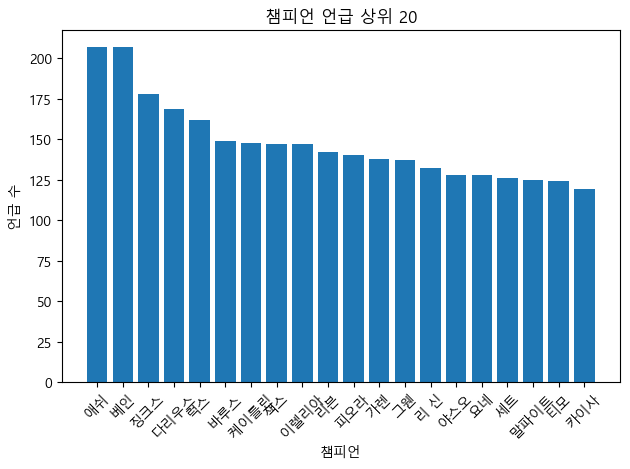

In [68]:
# 텍스트 컬럼에서 특정 키워드들의 등장 여부를 기준으로 빈도 계산
champ_freq = {}

for champ, patterns in champion_patterns.items():
    total = 0
    for p in patterns:
        pattern = rf'(?<![가-힣]){re.escape(p)}(?![가-힣])'
        total += df_transform["text_no_space"].str.contains(pattern, regex=True, na=False).sum()

    if total > 0:
        champ_freq[champ] = total

total_comments = len(df_transform)

champ_df = pd.DataFrame({
    "champion": list(champ_freq.keys()),
    "count": list(champ_freq.values())
})

champ_df["percent"] = (champ_df["count"] / total_comments * 100).round(2)
champ_df = champ_df.sort_values(by="count", ascending=False).reset_index(drop=True)

print("언급된 챔피언 수:", len(champ_freq))

print("==== 챔피언 언급 통계 ====")
print(champ_df)

# 챔피언 상위 20 그래프
top20 = champ_df.head(20)
plt.figure()
plt.bar(top20["champion"], top20["count"])
plt.title("챔피언 언급 상위 20")
plt.xlabel("챔피언")
plt.ylabel("언급 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

==== 포지션 언급 통계 ====
  position  count  percent
0        탑   7687     6.54
1       정글   9490     8.08
2       미드   5227     4.45
3   원거리 딜러   9587     8.16
4      서포터   7751     6.60


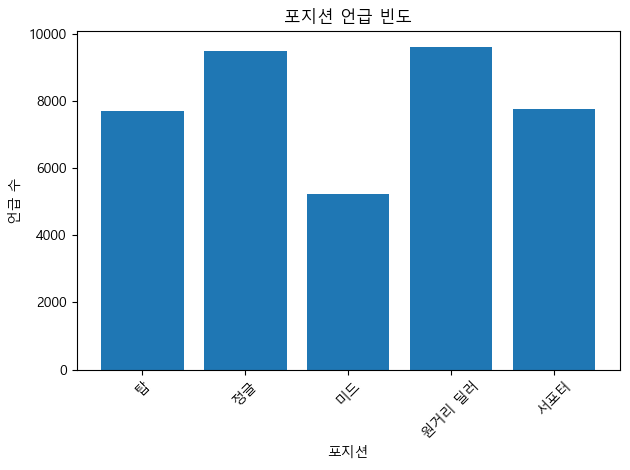

In [69]:
# 포지션 언급 빈도
pos_results = []

for pos, keywords in position_dict.items():
    mask = False
    for k in keywords:
        mask |= df_transform["translated_text"].str.contains(k, na=False)
    count = mask.sum()
    pos_results.append((pos, count))

pos_df = pd.DataFrame(pos_results, columns=["position", "count"])
pos_df["percent"] = (pos_df["count"] / total_comments * 100).round(2)

print("==== 포지션 언급 통계 ====")
print(pos_df)

# 포지션 그래프
plt.figure()
plt.bar(pos_df["position"], pos_df["count"])
plt.title("포지션 언급 빈도")
plt.xlabel("포지션")
plt.ylabel("언급 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [70]:
# 원인/성과 키워드 
def keyword_count(keyword_list):
    total = 0
    for k in keyword_list:
        total += df_transform["translated_text"].str.contains(k, na=False).sum()
    return total

cause_count = keyword_count(cause_keywords)
performance_count = keyword_count(performance_keywords)

print("원인 키워드 총합:", cause_count)
print("성과 키워드 총합:", performance_count)

원인 키워드 총합: 9570
성과 키워드 총합: 24233


In [71]:
# 감성 분석
df_transform["sentiment"] = df_transform["translated_text"].apply(lambda x: TextBlob(x).sentiment.polarity)

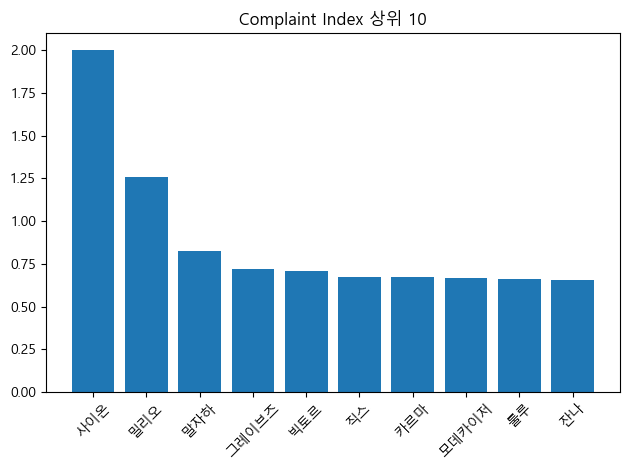

In [72]:
# Complaint Index 계산
complaint_index = {}

for champ, patterns in champion_patterns.items():

    mask_total = pd.Series(False, index=df_transform.index)

    for p in patterns:
        pattern = rf'(?<![가-힣]){re.escape(p)}(?![가-힣])'
        mask_total |= df_transform["text_no_space"].str.contains(pattern, regex=True, na=False)

    total = mask_total.sum()
    if total == 0:
        continue

    neg = df_transform.loc[mask_total, "translated_text"].str.contains("|".join(negative_keywords), na=False).sum()
    stress = df_transform.loc[mask_total, "translated_text"].str.contains("|".join(stress_keywords), na=False).sum()
    cause = df_transform.loc[mask_total, "translated_text"].str.contains("|".join(cause_keywords), na=False).sum()

    complaint_index[champ] = (neg + stress + cause) / total

# 상위 10 시각화
top_complaint = dict(sorted(complaint_index.items(), key=lambda x: x[1], reverse=True)[:10])

plt.figure()
plt.bar(top_complaint.keys(), top_complaint.values())
plt.xticks(rotation=45)
plt.title("Complaint Index 상위 10")
plt.tight_layout()
plt.show()

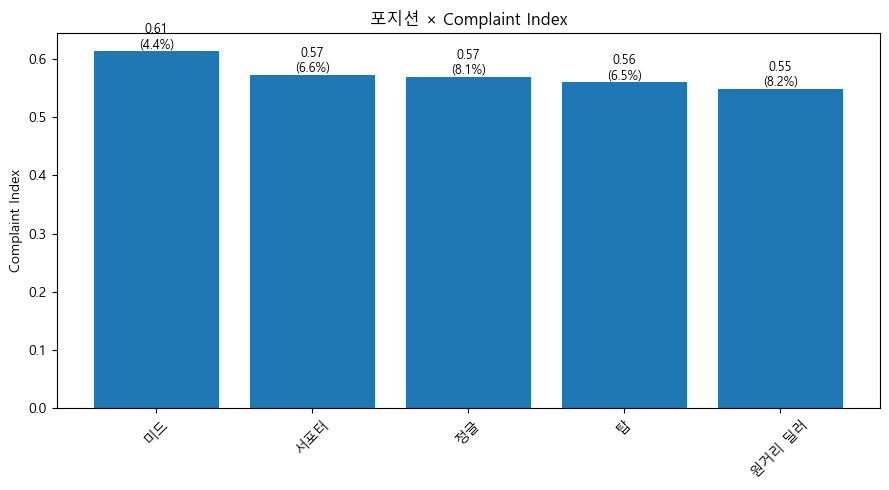

In [230]:
# 포지션별 Complaint Index
def plot_position_complaint_index(df):

    results = []

    total_comments = len(df)

    for pos, keywords in position_dict.items():

        mask = pd.Series(False, index=df.index)

        for k in keywords:
            mask |= df["translated_text"].str.contains(k, na=False)

        sub = df[mask]

        if len(sub) == 0:
            continue

        neg = sub["translated_text"].str.contains("|".join(negative_keywords), na=False).sum()
        stress = sub["translated_text"].str.contains("|".join(stress_keywords), na=False).sum()
        cause = sub["translated_text"].str.contains("|".join(cause_keywords), na=False).sum()

        complaint_index = (neg + stress + cause) / len(sub)

        results.append({
            "position": pos,
            "complaint_index": complaint_index,
            "ratio": len(sub) / total_comments * 100
        })

    result_df = pd.DataFrame(results).sort_values("complaint_index", ascending=False)

    # 시각화
    plt.figure(figsize=(9,5))

    bars = plt.bar(result_df["position"], result_df["complaint_index"])

    plt.title("포지션 × Complaint Index")
    plt.ylabel("Complaint Index")

    # 값 + 비율 표시
    for i, bar in enumerate(bars):

        height = bar.get_height()
        ratio = result_df["ratio"].iloc[i]

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}\n({ratio:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return result_df

pos_complaint_df = plot_position_complaint_index(df_transform)


==== 언급되지 않은 챔피언 ====
['나르', '문도 박사', '신 짜오', '흐웨이']
총 4 명


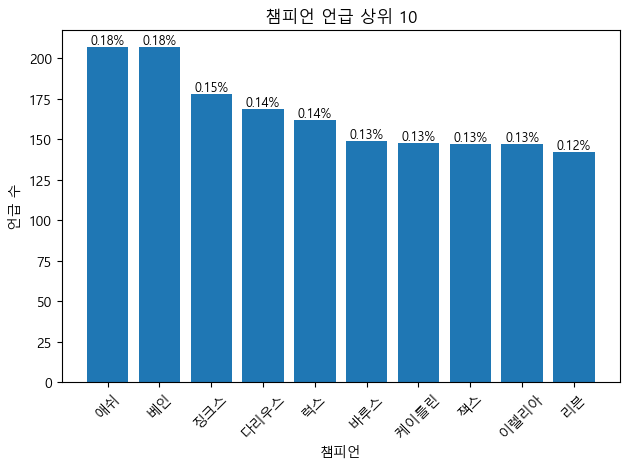

In [78]:
def get_unmentioned_champions(champion_list, champ_df):
    mentioned = set(champ_df[champ_df["count"] > 0]["champion"])
    return [champ for champ in champion_list if champ not in mentioned]

unmentioned_list = get_unmentioned_champions(champion_list, champ_df)

print("\n==== 언급되지 않은 챔피언 ====")
print(unmentioned_list)
print("총", len(unmentioned_list), "명")

# 상위 20 그래프 (빈도 % 표시)
top10 = champ_df.head(10)

plt.figure()
bars = plt.bar(top10["champion"], top10["count"])

plt.title("챔피언 언급 상위 10")
plt.xlabel("챔피언")
plt.ylabel("언급 수")
plt.xticks(rotation=45)

# 퍼센트 표시
for i, bar in enumerate(bars):
    height = bar.get_height()
    percent = top10["percent"].iloc[i]

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{percent}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

=== 감성 점수 낮은 챔피언 TOP10 ===
    champion  avg_sentiment
98        오공      -0.150000
13        니코      -0.020270
40         멜      -0.013158
139     칼리스타      -0.012500
145      코르키      -0.011538
31       르블랑      -0.008333
143       케일      -0.006356
129      징크스      -0.002887
103       요네      -0.001172
64      사일러스      -0.000177
=== 감성 점수 높은 챔피언 TOP10 ===
    champion  avg_sentiment
101     오리아나       0.024003
53      볼리베어       0.026119
137      카직스       0.026316
79       신지드       0.026786
55      브라이어       0.026874
4      그레이브즈       0.027127
10        녹턴       0.029545
2       갱플랭크       0.031813
8        나피리       0.045455
61        뽀삐       0.080000


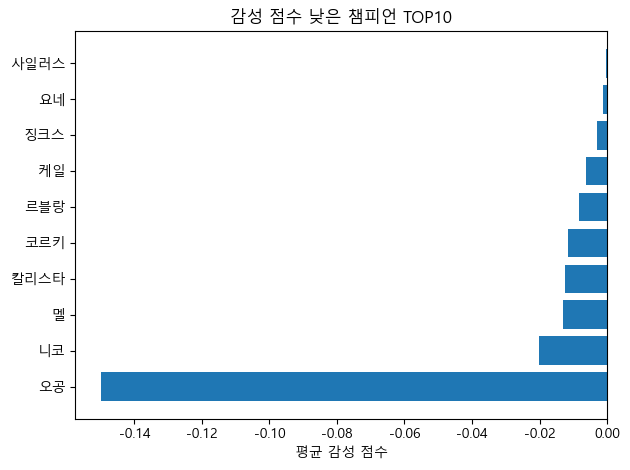

In [79]:
# 챔피언별 평균 감성 점수 계산
champ_sentiment = {}

for champ, patterns in champion_patterns.items():

    mask = pd.Series(False, index=df_transform.index)

    for p in patterns:
        pattern = rf'(?<![가-힣]){re.escape(p)}(?![가-힣])'
        mask |= df_transform["text_no_space"].str.contains(pattern, regex=True, na=False)

    if mask.sum() > 0:
        champ_sentiment[champ] = df_transform.loc[mask, "sentiment"].mean()

# 데이터프레임화
champ_sent_df = pd.DataFrame({
    "champion": champ_sentiment.keys(),
    "avg_sentiment": champ_sentiment.values()
}).sort_values("avg_sentiment")

print("=== 감성 점수 낮은 챔피언 TOP10 ===")
print(champ_sent_df.head(10))

print("=== 감성 점수 높은 챔피언 TOP10 ===")
print(champ_sent_df.tail(10))

# 시각화
top_negative = champ_sent_df.head(10)

plt.figure()
plt.barh(top_negative["champion"], top_negative["avg_sentiment"])
plt.title("감성 점수 낮은 챔피언 TOP10")
plt.xlabel("평균 감성 점수")
plt.tight_layout()
plt.show()

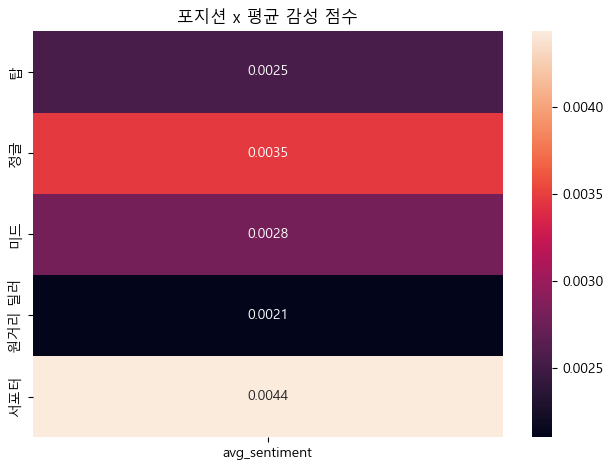

In [89]:
position_sentiment = {}

for pos, keywords in position_dict.items():

    mask = pd.Series(False, index=df_transform.index)

    for k in keywords:
        mask |= df_transform["translated_text"].str.contains(k, na=False)

    if mask.sum() > 0:
        position_sentiment[pos] = df_transform.loc[mask, "sentiment"].mean()

pos_sent_df = pd.DataFrame.from_dict(position_sentiment, orient="index", columns=["avg_sentiment"])

plt.figure()
sns.heatmap(pos_sent_df, annot=True)
plt.title("포지션 x 평균 감성 점수")
plt.tight_layout()
plt.show()

=== 상위 30 단어 ===
    word  count
0     있는  13072
1   있습니다  11999
2     저는  11955
3     다른  10438
4    하지만   9377
5     모든   9015
6     게임   8915
7    때문에   8864
8     제가   8822
9    게임을   8786
10    가장   8223
11   겁니다   7934
12    하는   7628
13   같아요   7448
14   거예요   7284
15  챔피언을   7160
16    같은   7155
17    리그   7095
18    훨씬   6958
19    좋은   6871
20    오브   6864
21   원거리   6028
22   합니다   5796
23   그리고   5647
24  사람들이   5429
25    이런   5353
26    수도   5203
27    어떤   5198
28    많이   5175
29    거의   5060


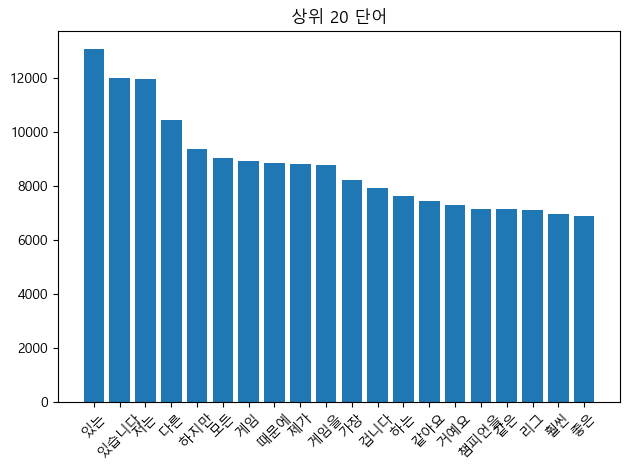

In [90]:
# 전체 텍스트 합치기
all_text = " ".join(df_transform["translated_text"].astype(str))

# 한글 2글자 이상 추출
tokens = re.findall(r"\b[가-힣]{2,}\b", all_text)

# 불용어
stopwords = ["진짜","너무","그냥","약간","이거","저거","때문","정말","생각"]

filtered_tokens = [t for t in tokens if t not in stopwords]

word_counts = Counter(filtered_tokens)

top_words = word_counts.most_common(30)

word_df = pd.DataFrame(top_words, columns=["word","count"])

print("=== 상위 30 단어 ===")
print(word_df)

# 막대 그래프
top_word_df = word_df.head(20)

plt.figure()
plt.bar(top_word_df["word"], top_word_df["count"])
plt.xticks(rotation=45)
plt.title("상위 20 단어")
plt.tight_layout()
plt.show()

In [93]:
def extract_word_counts(text_series):

    all_text = " ".join(text_series.dropna().astype(str))
    tokens = re.findall(r"\b[가-힣]{2,}\b", all_text)
    stopwords = ["진짜","너무","그냥","약간","이거","저거","때문","정말","생각"]
    filtered = [t for t in tokens if t not in stopwords]
    word_counts = Counter(filtered)

    # WordCloud용 dict 변환 (안전장치)
    word_counts = {k:int(v) for k,v in word_counts.items() if isinstance(k,str)}

    return word_counts

In [94]:
positive_df = df_transform[df_transform["sentiment"] > 0]
negative_df = df_transform[df_transform["sentiment"] < 0]

positive_words = extract_word_counts(positive_df["translated_text"])
negative_words = extract_word_counts(negative_df["translated_text"])

print("긍정 단어 수:", len(positive_words))
print("부정 단어 수:", len(negative_words))

긍정 단어 수: 10203
부정 단어 수: 5438


In [102]:
print(type(positive_words))
print(list(positive_words.items())[:5])

<class 'dict'>
[('농담에', 1), ('맞춰주셔서', 1), ('감사합니다', 13), ('럭스', 7), ('서포터가', 31)]


In [108]:
print(os.listdir("C:/Windows/Fonts"))

['8514fix.fon', '8514fixe.fon', '8514fixg.fon', '8514fixr.fon', '8514fixt.fon', '8514oem.fon', '8514oeme.fon', '8514oemg.fon', '8514oemr.fon', '8514oemt.fon', '8514sys.fon', '8514syse.fon', '8514sysg.fon', '8514sysr.fon', '8514syst.fon', '85775.fon', '85855.fon', '85f1255.fon', '85f1256.fon', '85f1257.fon', '85f874.fon', '85s1255.fon', '85s1256.fon', '85s1257.fon', '85s874.fon', 'ACaslonPro-Bold.otf', 'ACaslonPro-BoldItalic.otf', 'ACaslonPro-Italic.otf', 'ACaslonPro-Regular.otf', 'ACaslonPro-Semibold.otf', 'ACaslonPro-SemiboldItalic.otf', 'AdobeArabic-Bold.otf', 'AdobeArabic-BoldItalic.otf', 'AdobeArabic-Italic.otf', 'AdobeArabic-Regular.otf', 'AdobeDevanagari-Bold.otf', 'AdobeDevanagari-BoldItalic.otf', 'AdobeDevanagari-Italic.otf', 'AdobeDevanagari-Regular.otf', 'AdobeFangsongStd-Regular.otf', 'AdobeFanHeitiStd-Bold.otf', 'AdobeGothicStd-Bold.otf', 'AdobeHebrew-Bold.otf', 'AdobeHebrew-BoldItalic.otf', 'AdobeHebrew-Italic.otf', 'AdobeHebrew-Regular.otf', 'AdobeHeitiStd-Regular.otf', '

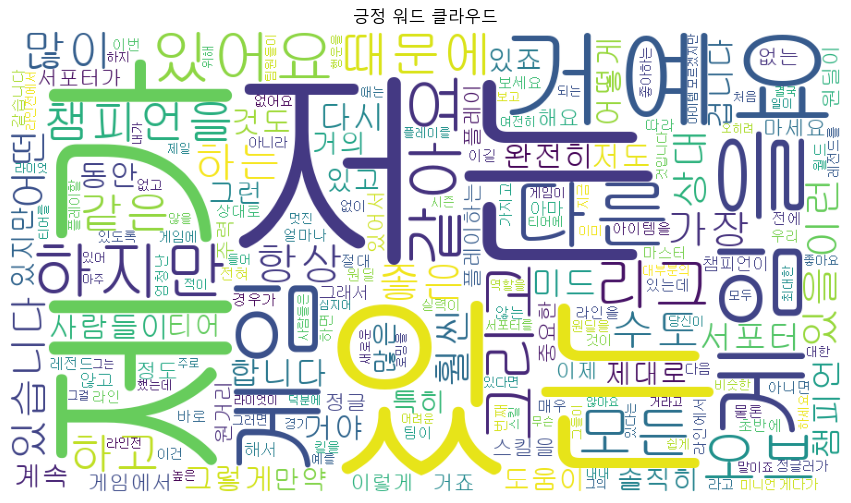

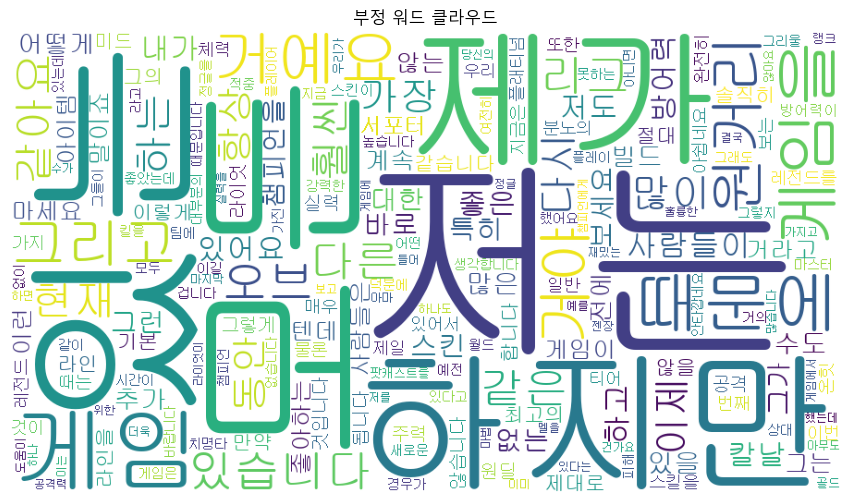

In [106]:
# 워드 클라우드
# 긍정
font_path = "C:/Windows/Fonts/gulim.ttc"

if len(positive_words) > 0:
    wc_pos = WordCloud(
        font_path=font_path,
        background_color="white",
        width=900,
        height=500
    ).generate_from_frequencies(positive_words)

    plt.figure(figsize=(12,6))
    plt.imshow(wc_pos)
    plt.axis("off")
    plt.title("긍정 워드 클라우드")
    plt.show()
else:
    print("긍정 데이터가 부족합니다.")

# 부정
if len(negative_words) > 0:
    wc_neg = WordCloud(
        font_path=font_path,
        background_color="white",
        width=900,
        height=500
    ).generate_from_frequencies(negative_words)

    plt.figure(figsize=(12,6))
    plt.imshow(wc_neg)
    plt.axis("off")
    plt.title("부정 워드 클라우드")
    plt.show()
else:
    print("부정 데이터가 부족합니다.")

In [ ]:
# 챔피언 워드

In [109]:
df_transform["month"] = (
    pd.to_datetime(
        df_transform["post_created_dt"],
        format="mixed",
        errors="coerce"
    )
    .dt.to_period("M")
)

In [113]:
parsed = pd.to_datetime(
    df_transform["post_created_dt"],
    errors="coerce"
)

# 변환 실패한 행 확인
bad_rows = df_transform[parsed.isna()]
print("변환 실패 개수:", len(bad_rows))
print(bad_rows["post_created_dt"].head(10))

변환 실패 개수: 85796
41    2025-07-06 15:54:23
42    2025-07-06 15:54:23
43    2025-07-06 15:54:23
44    2025-07-06 15:54:23
45    2025-07-06 15:54:23
46    2025-07-06 15:54:23
47    2025-07-06 15:54:23
48    2025-07-06 15:54:23
49    2025-07-06 15:54:23
50    2025-07-06 15:54:23
Name: post_created_dt, dtype: object


In [114]:
df_transform["post_created_dt"] = (
    df_transform["post_created_dt"]
    .astype(str)
    .str.replace(".", "-", regex=False)
    .str.replace("/", "-", regex=False)
)

df_transform["post_created_dt"] = pd.to_datetime(
    df_transform["post_created_dt"],
    errors="coerce"
)

df_transform["month"] = df_transform["post_created_dt"].dt.to_period("M")

In [115]:
print(df_transform["post_created_dt"].dtype)
print(df_transform["post_created_dt"].isna().sum())

datetime64[ns]
85796


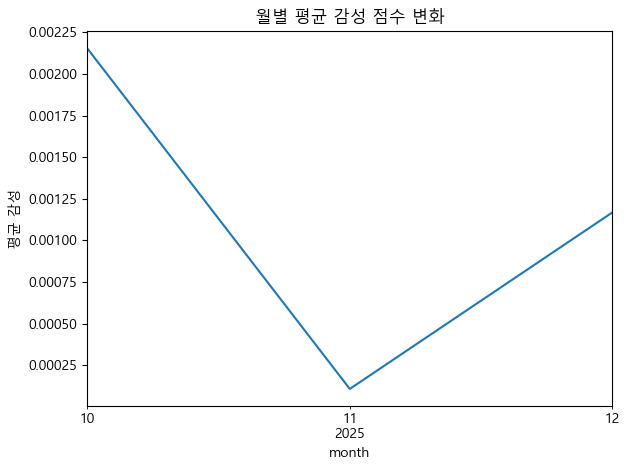

In [116]:
# 패치 이후 감성 변화
df_transform["month"] = pd.to_datetime(df_transform["post_created_dt"]).dt.to_period("M")

monthly_sent = df_transform.groupby("month")["sentiment"].mean()

plt.figure()
monthly_sent.plot()
plt.title("월별 평균 감성 점수 변화")
plt.ylabel("평균 감성")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [117]:
# 교차표
def champion_cause_crosstab(df, champion_list, cause_keywords):

    rows = []

    for _, row in df.iterrows():
        text = str(row["translated_text"])

        for champ in champion_list:
            if champ in text:
                for keyword in cause_keywords:
                    if keyword in text:
                        rows.append((champ, keyword))

    temp = pd.DataFrame(rows, columns=["champion","cause"])

    return pd.crosstab(temp["champion"], temp["cause"])

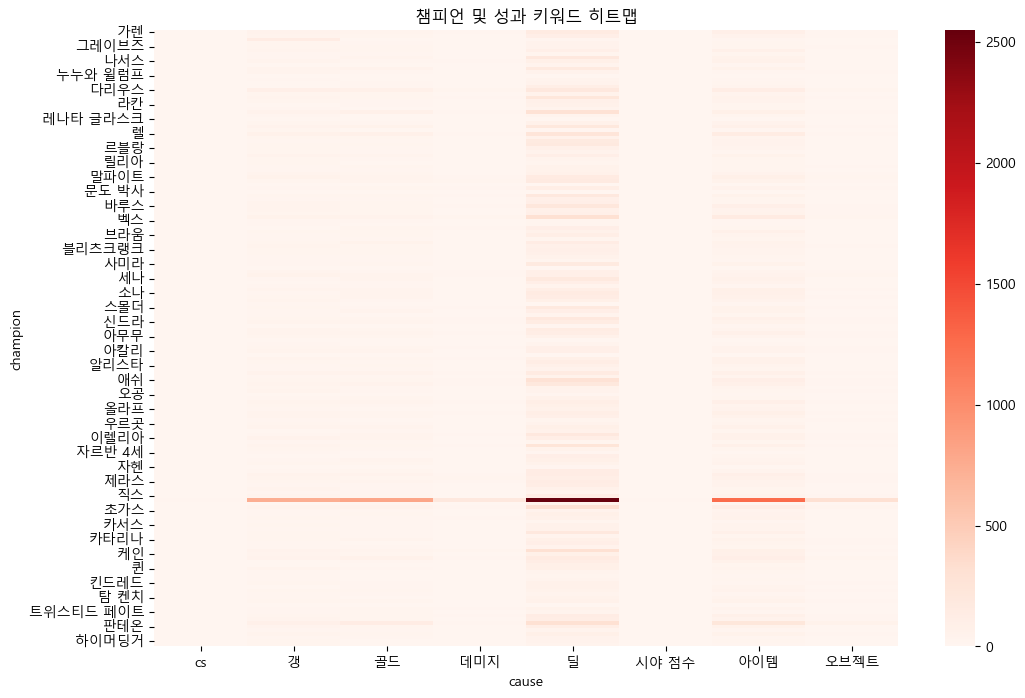

In [118]:
# 챔피언과 성과 키워드 히트맵
perf_table = champion_cause_crosstab(
    df_transform,
    champion_list,
    performance_keywords
)

plt.figure(figsize=(12,8))
sns.heatmap(perf_table, cmap="Reds")
plt.title("챔피언 및 성과 키워드 히트맵")
plt.show()

In [121]:
import networkx as nx
from itertools import combinations
from collections import Counter

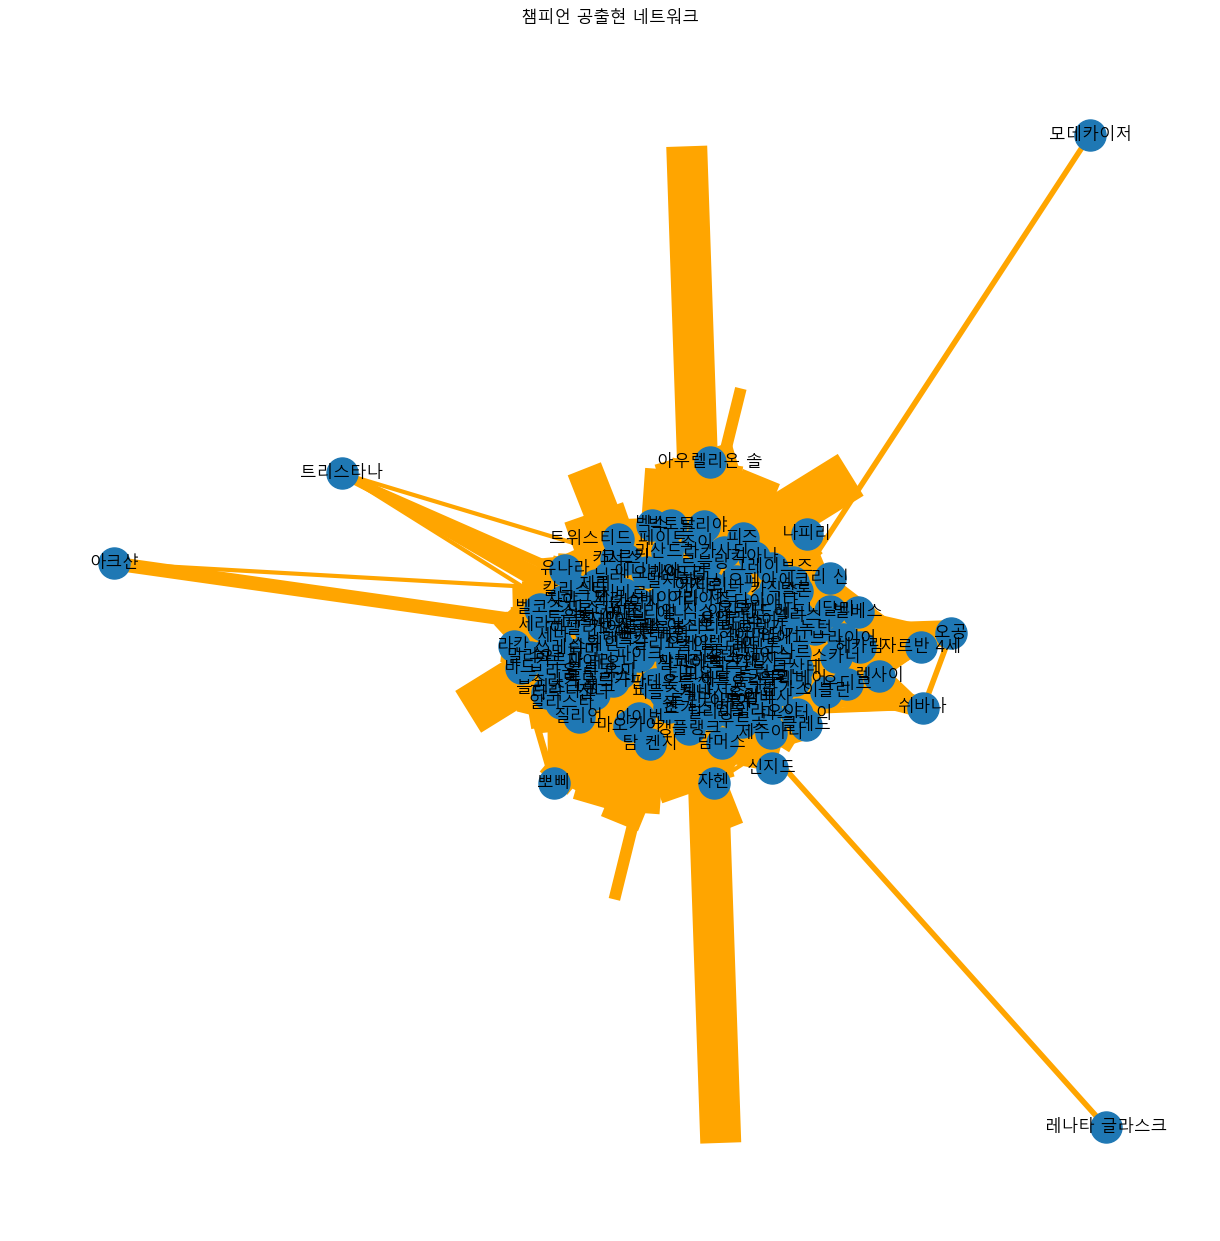

In [129]:
"""
● 노드 = 단어 또는 챔피언
─ 선 = 같은 글에서 같이 등장
선이 두꺼울수록 = 같이 많이 언급됨
"""
def build_cooccurrence_network(df, champion_list):

    pair_counter = Counter()

    for text in df["translated_text"].astype(str):

        present = [c for c in champion_list if c in text]

        for pair in combinations(present, 2):
            pair_counter[pair] += 1

    G = nx.Graph()

    for (a,b), weight in pair_counter.items():
        if weight >= 3:   # 최소 3회 이상만 연결
            G.add_edge(a, b, weight=weight)

    return G

G = build_cooccurrence_network(df_transform, champion_list)

plt.figure(figsize=(12,12))
pos = nx.spring_layout(G, k=0.5)

weights = [G[u][v]['weight'] for u,v in G.edges()]

nx.draw(G,pos,with_labels=True,node_size=500,width=weights,edge_color="orange",font_family="Malgun Gothic")

plt.title("챔피언 공출현 네트워크")
plt.show()

In [167]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 토픽 모델링
vectorizer = CountVectorizer(
    max_df=0.9,
    min_df=5,
    stop_words=None
)

X = vectorizer.fit_transform(df_transform["translated_text"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

def print_topics(model, feature_names, n_top_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"\nTopic {idx+1}")
        print([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])

print_topics(lda, vectorizer.get_feature_names_out())


Topic 1
['있습니다', '원거리', '다른', '모든', '때문에', '가장', '있는', '겁니다', '하지만', '합니다']

Topic 2
['정말', '너무', '같아요', '진짜', '거예요', '솔직히', '거야', '그냥', '월드', '그는']

Topic 3
['있습니다', '챔피언을', '있는', '하지만', '겁니다', '가장', '다른', '합니다', '게임을', '훨씬']

Topic 4
['quot', '리그', '오브', '게임을', '정말', '저는', '하는', '게임', '제가', '사람들이']

Topic 5
['저는', '스킬을', '제가', '미드', '상대', '있는', '라인', '있습니다', '라인을', '미니언']


In [133]:
df_transform["translated_text"].head(20).tolist()

['상대 원거리 딜러가 나보다 아이템 하나 앞서 있으면 미드로 달려간다.',
 '원거리 딜러 중에는 초반에 밀리면 따라잡기 매우 어려운 챔피언들이 많습니다. 하지만 0/1이라는 스코어가 게임을 끝내는 것은 아닙니다.',
 '징크스는 여기서 쓰기에 적합한 챔피언이 아닙니다. 징크스는 상대하기 가장 무서운 챔피언 중 하나인데, 한 번의 리셋으로 바로 죽기 때문입니다.',
 '당신은 원거리 딜러 주력 유저는 아니시죠?',
 '그 시점에서 8/0 다이러스로 0/8 볼리베리에게 죽는다면, 그건 순전히 실력 차이일 뿐입니다.',
 '징크스를 상대로 BT를 무작정 돌리면 처형당해야 마땅해 ㅋㅋㅋ',
 '하지만 이건 사실이 아니에요. 제 생각엔 원딜이 중반 게임에서 정말 강력한 매크로 역할인 것 같아요. 예를 들어, 라인전에서 제가 엄청난 격차를 벌리고 나서 상대 원딜이 그 우위를 제대로 활용하지 못하는 게임이 너무 많아요.',
 '오히려 반대여야 하는 거 아닌가요?',
 '저는 평생 한 번도 항복한 적이 없어요. 럭셔리 아이템 두 개가 부족할 때조차도요.',
 '야, 나 유나라로 루시안 상대로 0/4 했어. 걔가 완전 빡세게 몰아쳤는데, 난 매크로랑 마이크로 컨트롤을 잘하면서 계속 게임을 운영했지. 20분쯤 되니까 걔가 15/4였는데, 우리가 걔네 팀을 따라잡고 오브젝트를 챙기면서 계속 따라잡다 결국 이겼어. 40분짜리 게임이었는데, 초반에 죽는다고 세상 끝나는 건 아니잖아. 매크로랑 마이크로 컨트롤만 잘하면 돼.',
 '- 나 - 20/4/10 미드 AP 제리 - 궁극기/우클릭/평타(어둠의 수확 효과 발동)로 루시안을 한 방에 처치해, 심지어 보호막이 뚫려도 - 솔직히 말해서, 난 엄청 잘 성장해서 상대 팀의 탱커를 제외한 거의 모든 챔피언을 한 방에 잡을 수 있어 - 그런데 루시안이 내가 만피인 상태에서 여섯 번째로 돌진해 들어와 - 내가 궁극기/우클릭/평타를 쓸 수 있는 0.5초 만에 내 체력을 10%까지 깎아버렸어 - 루시안은 4/19/6이었는데 - 음, 지금은 4

In [149]:
df_transform["clean_text"] = (
    df_transform["translated_text"]
    .astype(str)
    .str.replace("&quot;", " ", regex=False)
    .str.replace("quot", " ", regex=False)
    .str.replace(r"[^가-힣a-zA-Z0-9\s]", " ", regex=True)
)

In [162]:
def get_top_tfidf_keywords(df, text_col="translated_text", top_n=20):

    # None 제거
    texts = df[text_col].dropna().astype(str)

    vectorizer = TfidfVectorizer(
        max_df=0.9,      # 너무 흔한 단어 제거
        min_df=5,        # 너무 희귀한 단어 제거
        ngram_range=(1,1),
        stop_words=["quot","오브", "제가","저는","나는","내가"]
    )

    X = vectorizer.fit_transform(texts)

    # 단어별 평균 TF-IDF 점수 계산
    mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()

    tfidf_df = pd.DataFrame({
        "term": terms,
        "score": mean_tfidf
    }).sort_values("score", ascending=False)

    tfidf_df = tfidf_df[
        (~tfidf_df["term"].isin(champion_list)) &
        (tfidf_df["term"] != "quot")
    ]

    return tfidf_df.head(top_n)

top_keywords = get_top_tfidf_keywords(df_transform, top_n=20)
print(top_keywords)

       term     score
33294    정말  0.015119
8443     너무  0.009604
31226    있는  0.009057
9547     다른  0.007274
31259  있습니다  0.007228
15043    모든  0.007096
4320     게임  0.007003
3923     거야  0.006966
4361    게임을  0.006939
3937    거예요  0.006717
3605    같아요  0.006669
13163    리그  0.006647
2906     가장  0.006626
6227     그냥  0.006613
41720   하지만  0.006253
35577    진짜  0.006196
4158    겁니다  0.006116
41569    하는  0.006115
12179   때문에  0.006054
34266    좋은  0.005702


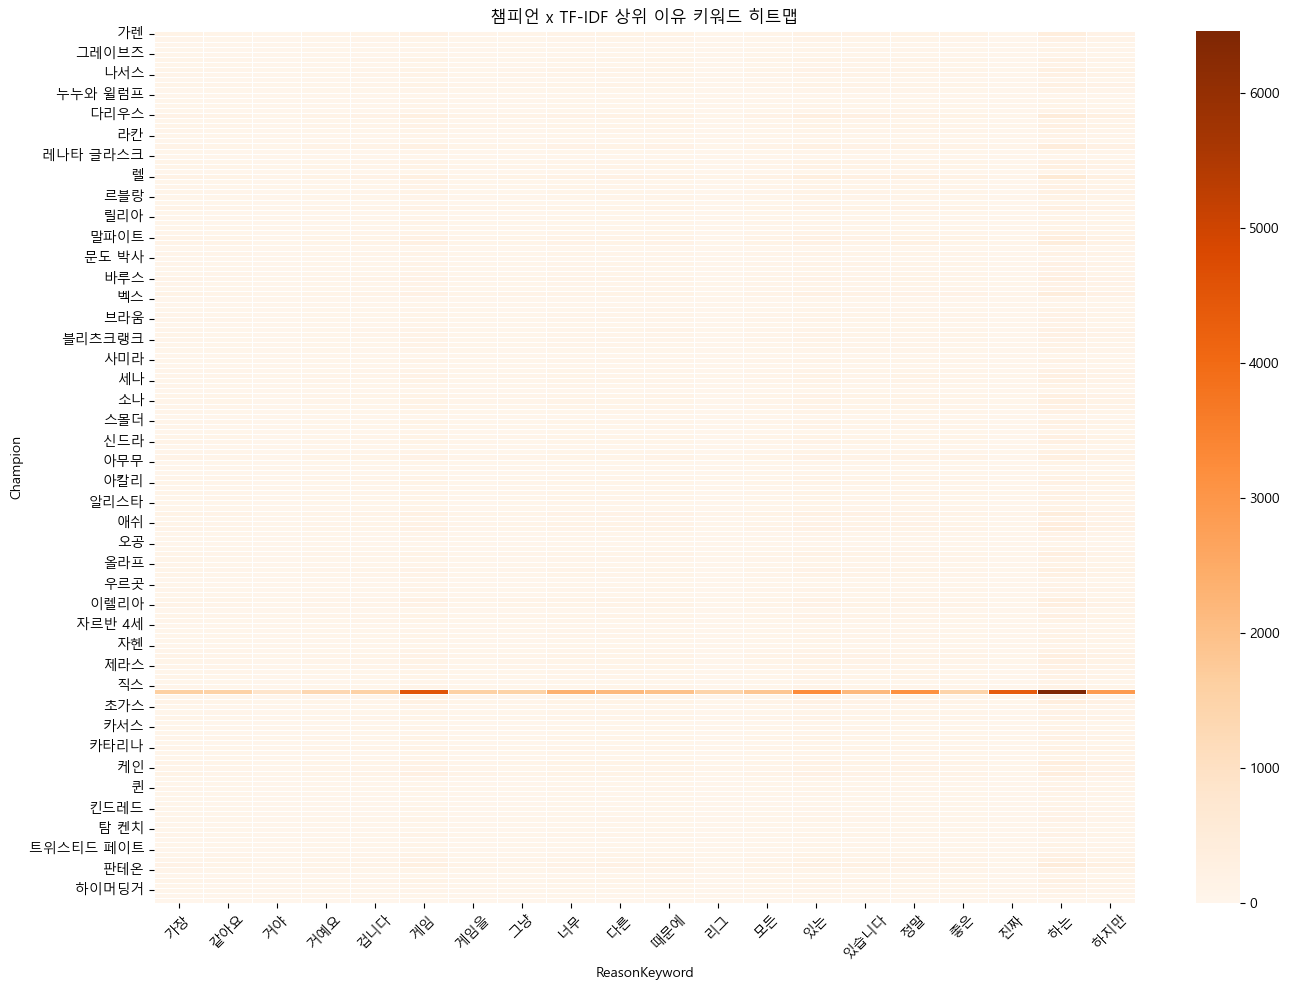

In [163]:
top_keywords = top_keywords[~top_keywords["term"].isin(champion_list)]

reason_keywords = top_keywords["term"].tolist()

# 챔피언 TF-IDF 키워드 교차표
def champion_tfidf_reason(df, champion_list, reason_keywords):

    rows = []

    for text in df["translated_text"].astype(str):

        champs = [c for c in champion_list if c in text]

        if not champs:
            continue

        for keyword in reason_keywords:
            if keyword in text:
                for champ in champs:
                    rows.append((champ, keyword))

    result = pd.DataFrame(rows, columns=["Champion","ReasonKeyword"])

    return pd.crosstab(result["Champion"], result["ReasonKeyword"])

reason_table = champion_tfidf_reason(df_transform,champion_list,reason_keywords)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    reason_table,
    cmap="Oranges",
    linewidths=0.5
)

plt.title("챔피언 x TF-IDF 상위 이유 키워드 히트맵")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

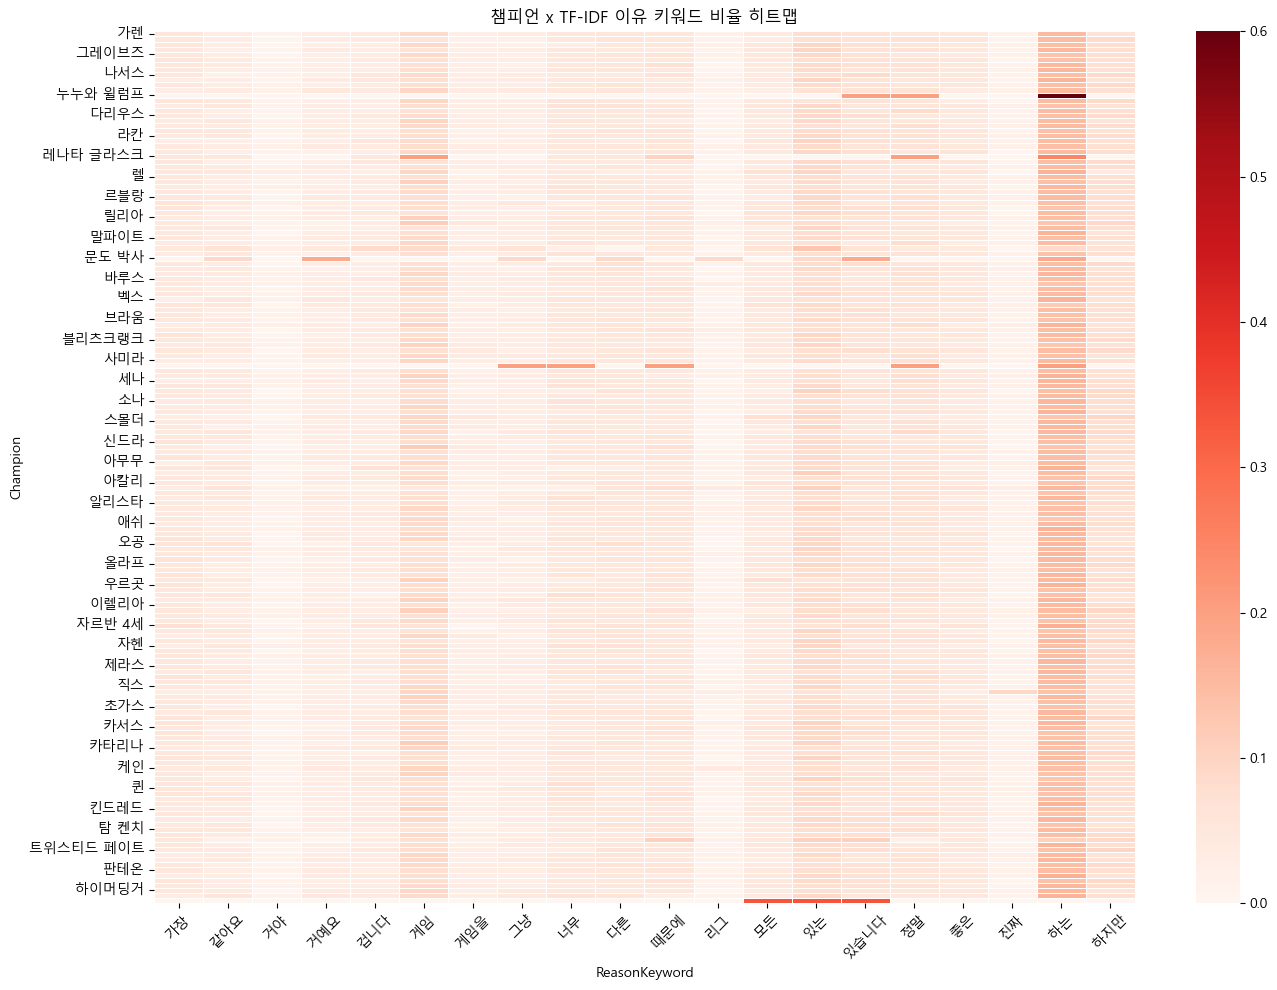

In [164]:
reason_ratio = reason_table.div(reason_table.sum(axis=1), axis=0)

plt.figure(figsize=(14,10))

sns.heatmap(
    reason_ratio,
    cmap="Reds",
    linewidths=0.5
)

plt.title("챔피언 x TF-IDF 이유 키워드 비율 히트맵")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

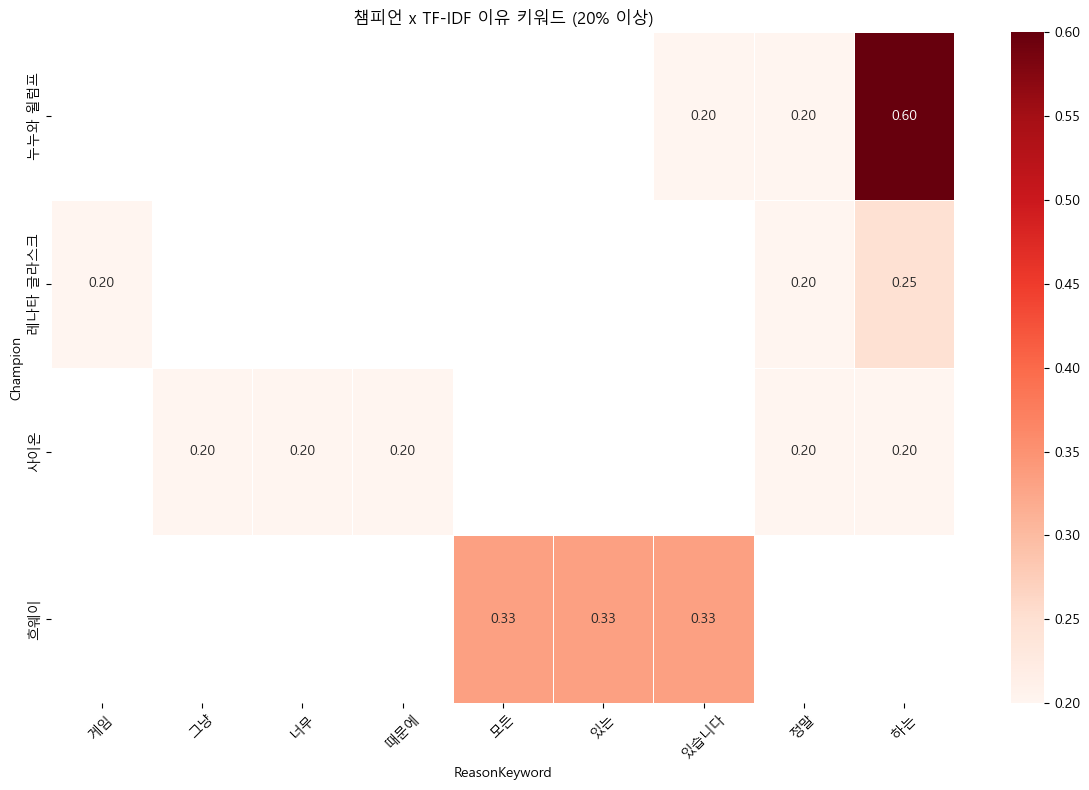

In [166]:
threshold = 0.20

filtered_ratio = reason_ratio.where(reason_ratio >= threshold)

filtered_ratio = filtered_ratio.dropna(how="all", axis=0)  # 행 제거
filtered_ratio = filtered_ratio.dropna(how="all", axis=1)  # 열 제거

filtered_ratio = reason_ratio[reason_ratio >= threshold]
filtered_ratio = filtered_ratio.dropna(how="all").dropna(how="all", axis=1)

plt.figure(figsize=(12,8))

sns.heatmap(
    filtered_ratio,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5
)

plt.title("챔피언 x TF-IDF 이유 키워드 (20% 이상)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [543]:
def simple_sentiment(text):
    text = str(text)
    pos = sum(word in text for word in positive_keywords)
    neg = sum(word in text for word in negative_keywords)

    if pos > neg:
        return "긍정"
    elif neg > pos:
        return "부정"
    else:
        return "중립"

In [544]:
def extract_champion_detail(df, champion, extra_keyword=None):

    df = df.copy()

    # 챔피언 포함 필터
    condition = df["translated_text"].astype(str).str.contains(champion, na=False)

    if extra_keyword:
        condition &= df["translated_text"].astype(str).str.contains(extra_keyword, na=False)

    temp_df = df[condition].copy()

    # 챔피언 컬럼 추가
    temp_df["Champion"] = champion

    # 댓글별 감성 계산
    temp_df["sentiment"] = temp_df["translated_text"].apply(simple_sentiment)

    # 댓글별 긍정/부정 키워드 비율 (각 댓글 기준)
    def comment_sentiment_ratio(text):

        text = str(text)

        pos = sum(word in text for word in positive_keywords)
        neg = sum(word in text for word in negative_keywords)

        total = pos + neg

        if total == 0:
            return 0, 0, 100   # 중립 100%

        return (
            round(pos/total*100, 2),
            round(neg/total*100, 2),
            round(100 - (pos+neg)/max(total,1)*100, 2)
        )

    # 댓글 단위 비율 계산 적용
    temp_df[["댓글_긍정(%)","댓글_부정(%)","댓글_중립(%)"]] = \
        temp_df["translated_text"].apply(
            lambda x: pd.Series(comment_sentiment_ratio(x))
        )

    return temp_df[[
        "Champion",
        "translated_text",
        "sentiment",
        "댓글_긍정(%)",
        "댓글_부정(%)",
        "댓글_중립(%)"
    ]]

In [274]:
nunu_result = extract_champion_detail(
    df_transform,
    "누누와 윌럼프"
)

sion_result = extract_champion_detail(
    df_transform,
    "사이온"
)

In [275]:
final_result = pd.concat([nunu_result, sion_result], ignore_index=True)

final_result

,Champion,translated_text,sentiment,댓글_긍정(%),댓글_부정(%),댓글_중립(%)
0,누누와 윌럼프,누누와 윌럼프를 상대로 플레이하는 건 괜찮아요.,긍정,100.00,0.00,0.0
1,누누와 윌럼프,누누와 윌럼프. 리워크 이후로 누누는 작은 소년이 거대한 생명체를 닮아 놀라운 디자...,중립,0.00,0.00,100.0
2,누누와 윌럼프,누누와 윌럼프는 샤코와 마찬가지로 1초 전까지만 해도 화면에 없던 것에 죽을 수도 ...,부정,0.00,100.00,0.0
3,누누와 윌럼프,"아니, 사람들이 누누와 윌럼프가 아이언맨보다 더 높은 순위에 오를 수 없다고 말하네.",중립,0.00,0.00,100.0
4,누누와 윌럼프,"누누와 윌럼프, 정말이지. 라이엇이 왜 자꾸 누누의 AP 계수를 올리고, 기회가 될...",부정,33.33,66.67,0.0
5,누누와 윌럼프,누누와 윌럼프,중립,0.00,0.00,100.0
6,누누와 윌럼프,"누누와 윌럼프 조합으로 웃는 건, 어차피 혼자서도 충분히 깰 수 있으니까... 진심...",부정,0.00,100.00,0.0
7,누누와 윌럼프,그 빌어먹을 누누와 윌럼프가 개를 죽이고 있어,부정,0.00,100.00,0.0
8,누누와 윌럼프,누누와 윌럼프 탑. 로드 오브 에이지스 탱커 빌드를 사용하세요. W 스킬로 마법사 ...,중립,0.00,0.00,100.0
9,누누와 윌럼프,누누와 윌럼프는 탑 라인이 좋습니다. 영겁의 지팡이를 맞추면 원거리 탑 라이너를 상...,중립,50.00,50.00,0.0


In [316]:
ziggs_result = extract_champion_detail(
    df_transform,
    "직스"
)

timmo_result = extract_champion_detail(
    df_transform,
    "티모"
)

In [373]:
final_result = pd.concat([ziggs_result, timmo_result], ignore_index=True)

final_result

,Champion,translated_text,sentiment,댓글_긍정(%),댓글_부정(%),댓글_중립(%)
0,직스,"이 빌드를 보면서도, 카직스가 룰루의 방패를 뚫고 당신을 죽이는 장면이 자꾸 떠올라요.",중립,0.00,0.00,100.0
1,직스,"아펠리오스는 총기류에 속해야 하고, 어쩌면 그 이상일 수도 있어요. 좀 애매하긴 하...",긍정,100.00,0.00,0.0
2,직스,직스를 없애버려. 걔는 미드 라이너인데 바텀 라인에서 뭐 하는 척만 하잖아.,부정,0.00,100.00,0.0
3,직스,"저는 바텀 라인에 마법사가 있는 건 괜찮지만, 포격형 마법사나 그 옆 라인에 마법사...",부정,33.33,66.67,0.0
4,직스,제 생각엔 봇 라인이 원거리 딜러가 존재하고 후반까지 성장할 수 있는 유일한 라인 ...,중립,50.00,50.00,0.0
...,...,...,...,...,...,...
1174,티모,피오라와 티모를 조합해서 멘탈이 흔들릴 때 활용하기 좋아요.,긍정,100.00,0.00,0.0
1175,티모,티모는 볼리베어와 다리우스의 확실한 카운터입니다. 티모에 대한 대책이 있으신가요? ...,부정,0.00,100.00,0.0
1176,티모,더러운 티모 플레이어,부정,0.00,100.00,0.0
1177,티모,"저는 제이스, 초파리, 티모, 말파이트로 리븐을 상대하는 걸 항상 좋아했어요. 핵심...",긍정,100.00,0.00,0.0


In [545]:
# 포지션별 댓글 조회
def extract_position_detail(df, position_dict):

    df = df.copy()

    results = []

    # 포지션별 분석
    for pos_name, keywords in position_dict.items():

        # OR 조건 검색
        condition = pd.Series(False, index=df.index)

        for kw in keywords:
            condition |= df["translated_text"].astype(str).str.contains(kw, na=False)

        temp_df = df[condition].copy()

        if len(temp_df) == 0:
            continue

        # 포지션 컬럼 (Champion 대신 Position)
        temp_df["Position"] = pos_name

        # 댓글별 감성
        temp_df["sentiment"] = temp_df["translated_text"].apply(simple_sentiment)

        # 댓글별 키워드 기반 비율 계산
        def comment_ratio(text):

            text = str(text)

            pos = sum(word in text for word in positive_keywords)
            neg = sum(word in text for word in negative_keywords)

            total = pos + neg

            if total == 0:
                return 0,0,100

            return (
                round(pos/total*100,2),
                round(neg/total*100,2),
                round(100 - (pos+neg)/max(total,1)*100,2)
            )

        temp_df[[
            "댓글_긍정(%)",
            "댓글_부정(%)",
            "댓글_중립(%)"
        ]] = temp_df["translated_text"].apply(
            lambda x: pd.Series(comment_ratio(x))
        )

        results.append(temp_df[[
            "Position",
            "translated_text",
            "sentiment",
            "댓글_긍정(%)",
            "댓글_부정(%)",
            "댓글_중립(%)"
        ]])

    return pd.concat(results, ignore_index=True)

In [410]:
position_result = extract_position_detail(df_transform,position_dict)
position_result

,Position,translated_text,sentiment,댓글_긍정(%),댓글_부정(%),댓글_중립(%)
0,탑,"네, 탑 라인에 대해 잘 이해 못 하시는 것 같네요. 양쪽 모두 적당히 잘하면 0/...",중립,50.00,50.00,0.0
1,탑,탑 라인에서 한 번 죽는다고 정글러가 도와주지 않으면 게임이 망하는 건 아니잖아. ...,부정,0.00,100.00,0.0
2,탑,"사실 탑 라인에서 그런 의견을 더 자주 들었는데, 제 운이 안 좋은 걸지도 모르겠네요.",긍정,100.00,0.00,0.0
3,탑,"봇 라인은 스노우볼링이 심하지만, 특히 돌진형 서포터와 함께 플레이한다면 역전할 가...",부정,0.00,100.00,0.0
4,탑,원거리 딜러(ADC) 입장에서는 상대 원거리 딜러가 5/0으로 죽어도 전혀 신경 안...,중립,0.00,0.00,100.0
...,...,...,...,...,...,...
39737,서포터,"당신은 &quot;내가 더 통제력을 가진 것 같아&quot;라고 말하지만, 그렇지 ...",중립,0.00,0.00,100.0
39738,서포터,"처음 게임을 시작했을 때는 서포터를 했었는데, 금방 질려서 탑으로 전향했고 그 이후...",부정,0.00,100.00,0.0
39739,서포터,"저는 탑 라인을 배우는 파이크 원챔 유저인데, 탑 라인이 정말 도움이 많이 되면서도...",부정,25.00,75.00,0.0
39740,서포터,제 생각에 핌불은 지금 괜찮은 위치에 있습니다. 보호막 재사용 대기시간을 없애자는 ...,부정,33.33,66.67,0.0


In [546]:
def extract_specific_position_detail(df, target_positions):

    df = df.copy()

    results = []

    for pos_name in target_positions:

        # 포지션 키워드 매칭
        condition = df["translated_text"].astype(str).str.contains(pos_name, na=False)

        temp_df = df[condition].copy()

        if len(temp_df) == 0:
            continue

        temp_df["position"] = pos_name

        # 댓글별 감성 분류
        temp_df["sentiment"] = temp_df["translated_text"].apply(simple_sentiment)

        # 댓글별 비율 계산
        def comment_ratio(text):

            text = str(text)

            pos = sum(word in text for word in positive_keywords)
            neg = sum(word in text for word in negative_keywords)

            total = pos + neg

            if total == 0:
                return 0,0,100

            return (
                round(pos/total*100,2),
                round(neg/total*100,2),
                round(100 - (pos+neg)/max(total,1)*100,2)
            )

        temp_df[[
            "댓글_긍정(%)",
            "댓글_부정(%)",
            "댓글_중립(%)"
        ]] = temp_df["translated_text"].apply(
            lambda x: pd.Series(comment_ratio(x))
        )

        results.append(temp_df[[
            "position",
            "translated_text",
            "sentiment",
            "댓글_긍정(%)",
            "댓글_부정(%)",
            "댓글_중립(%)"
        ]])

    return pd.concat(results, ignore_index=True)

In [412]:
position_result_support = extract_specific_position_detail(df_transform,["서포터","서폿"])
position_result_support


,position,translated_text,sentiment,댓글_긍정(%),댓글_부정(%),댓글_중립(%)
0,서포터,"봇 라인은 스노우볼링이 심하지만, 특히 돌진형 서포터와 함께 플레이한다면 역전할 가...",부정,0.00,100.00,0.0
1,서포터,이런 상황이 발생하면 그냥 모든 걸 무시하고 파워스파이크까지 파밍만 해요. 하지만 ...,부정,0.00,100.00,0.0
2,서포터,"사람들이 우선순위에 대해 비난하기 전에, 1대9 상황에서 승리하는 것은 언제나 서포...",중립,0.00,0.00,100.0
3,서포터,탑 라인은 예상치 못한 플레이로 상대를 압도할 여지가 더 많습니다. 원거리 딜러는 ...,부정,33.33,66.67,0.0
4,서포터,원거리 딜러(ADC)가 가장 어려운 역할인 이유는 단순히 필요한 메카닉이나 매크로 ...,부정,0.00,100.00,0.0
...,...,...,...,...,...,...
7746,서포터,"당신은 &quot;내가 더 통제력을 가진 것 같아&quot;라고 말하지만, 그렇지 ...",중립,0.00,0.00,100.0
7747,서포터,"처음 게임을 시작했을 때는 서포터를 했었는데, 금방 질려서 탑으로 전향했고 그 이후...",부정,0.00,100.00,0.0
7748,서포터,"저는 탑 라인을 배우는 파이크 원챔 유저인데, 탑 라인이 정말 도움이 많이 되면서도...",부정,25.00,75.00,0.0
7749,서포터,제 생각에 핌불은 지금 괜찮은 위치에 있습니다. 보호막 재사용 대기시간을 없애자는 ...,부정,33.33,66.67,0.0


In [539]:
position_result_jungle = extract_specific_position_detail(df_transform,["정글","정글러"])
position_result_jungle

,position,translated_text,sentiment,댓글_긍정(%),댓글_부정(%),댓글_중립(%)
0,정글,탑 라인에서 한 번 죽는다고 정글러가 도와주지 않으면 게임이 망하는 건 아니잖아. ...,부정,0.0,100.0,0.0
1,정글,"봇 라인은 스노우볼링이 심하지만, 특히 돌진형 서포터와 함께 플레이한다면 역전할 가...",부정,0.0,100.0,0.0
2,정글,원거리 딜러(ADC) 역할은 그야말로 고문입니다. 다른 라인으로 옮겨보면 다음과 같...,중립,50.0,50.0,0.0
3,정글,"챌린저 티어 정글러가 원딜로 마스터 티어까지 못 간다는 건, 우리가 게임에서 경쟁력...",부정,0.0,100.0,0.0
4,정글,원거리 딜러(ADC)는 게임 내내 영향을 미치는 세 가지 주요 변수가 있습니다. 1...,긍정,100.0,0.0,0.0
...,...,...,...,...,...,...
15159,정글러,탑 라인은 게임에 큰 영향을 미치지 않는다는 말이 맞습니다. 다른 라인들이 어느 정...,부정,25.0,75.0,0.0
15160,정글러,일반적으로 챔피언 폭이 좁은 것이 도움이 될 수 있습니다. 챔피언의 역할에 덜 신경...,부정,40.0,60.0,0.0
15161,정글러,"저는 프로게이머는 절대 아니고, 다리우스는 순전히 캐주얼하게 플레이하는 유저입니다....",부정,0.0,100.0,0.0
15162,정글러,"피오라로 나서스를 상대할 때, 미니언 웨이브가 느리게 나서스 쪽으로 밀려온다면, 웨...",긍정,100.0,0.0,0.0


In [547]:
def position_summary_table(df, position_dict):

    df = df.copy()

    result_list = []

    text_series = df["translated_text"].astype(str).str.lower()

    for pos_name, keywords in position_dict.items():

        mask = pd.Series(False, index=df.index)

        for kw in keywords:
            mask |= text_series.apply(
                lambda x: kw.lower() in x.replace(" ", "")
            )

        temp_df = df[mask]

        total_count = len(temp_df)

        if total_count == 0:
            continue

        # 숫자 감성 기준 분류
        positive_ratio = (temp_df["sentiment"] > 0).mean() * 100
        negative_ratio = (temp_df["sentiment"] < 0).mean() * 100
        neutral_ratio = (temp_df["sentiment"] == 0).mean() * 100

        result_list.append([
            pos_name,
            total_count,
            round(positive_ratio,2),
            round(negative_ratio,2),
            round(neutral_ratio,2)
        ])

    return pd.DataFrame(
        result_list,
        columns=[
            "Position",
            "Mention_Count",
            "Positive(%)",
            "Negative(%)",
            "Neutral(%)"
        ]
    ).sort_values("Positive(%)", ascending=False)

position_summary_df = position_summary_table(df_transform, position_dict)

print(position_summary_df)

  Position  Mention_Count  Positive(%)  Negative(%)  Neutral(%)
4      서포터           7751         1.15         0.22       98.63
1       정글           9490         0.94         0.22       98.84
3   원거리 딜러           6785         0.90         0.25       98.85
2       미드           5232         0.80         0.19       99.01
0        탑           7687         0.70         0.21       99.09


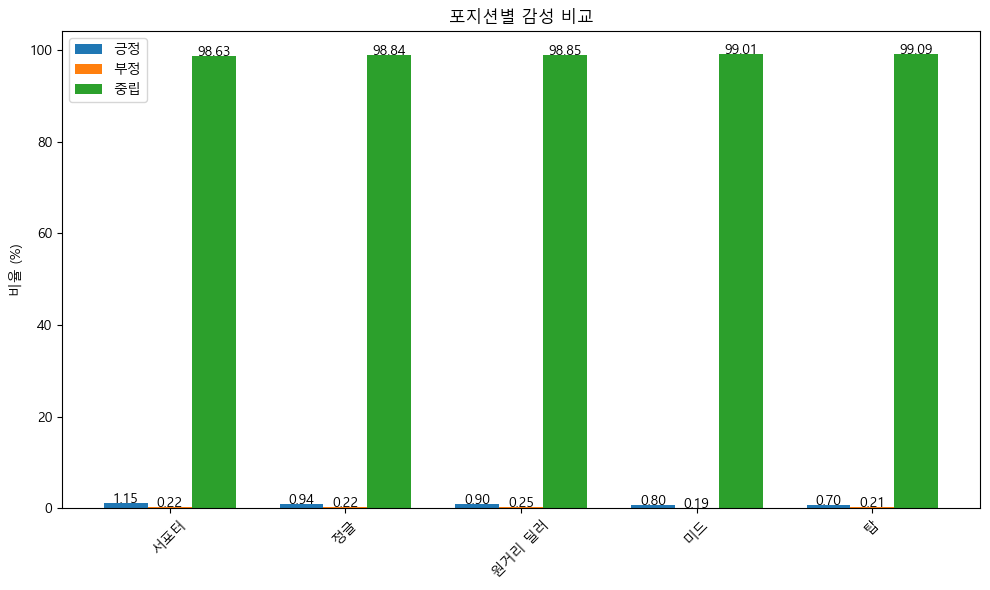

In [548]:
# 포지션별 감성 비교 그래프
def plot_position_sentiment_compare(summary_df):

    plt.figure(figsize=(10,6))

    x = range(len(summary_df))

    # 막대 그래프
    plt.bar(x, summary_df["Positive(%)"], width=0.25, label="긍정")
    plt.bar(
        [i+0.25 for i in x],
        summary_df["Negative(%)"],
        width=0.25,
        label="부정"
    )
    plt.bar(
        [i+0.5 for i in x],
        summary_df["Neutral(%)"],
        width=0.25,
        label="중립"
    )

    # X축
    plt.xticks(
        [i+0.25 for i in x],
        summary_df["Position"],
        rotation=45
    )

    plt.ylabel("비율 (%)")
    plt.title("포지션별 감성 비교")

    # 전체 비율 표시
    for i in x:

        # 긍정
        plt.text(
            i,
            summary_df["Positive(%)"].iloc[i],
            f"{summary_df['Positive(%)'].iloc[i]:.2f}",
            ha="center"
        )

        # 부정
        plt.text(
            i+0.25,
            summary_df["Negative(%)"].iloc[i],
            f"{summary_df['Negative(%)'].iloc[i]:.2f}",
            ha="center"
        )

        # 중립
        plt.text(
            i+0.5,
            summary_df["Neutral(%)"].iloc[i],
            f"{summary_df['Neutral(%)'].iloc[i]:.2f}",
            ha="center"
        )

    plt.legend()
    plt.tight_layout()
    plt.show()

plot_position_sentiment_compare(position_summary_df)

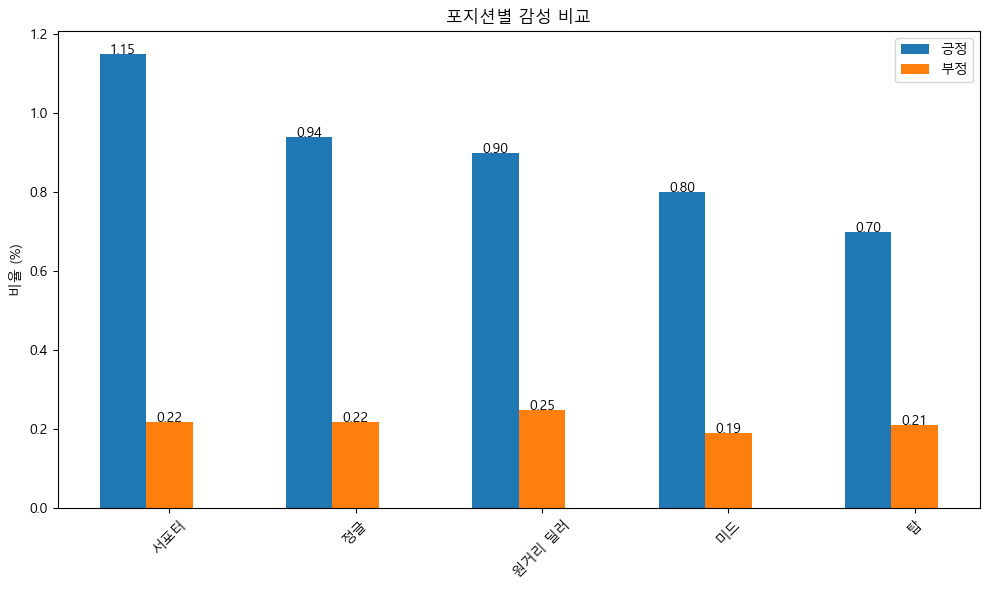

In [549]:
# 포지션별 감성 비교 그래프
def plot_position_sentiment_compare(summary_df):

    plt.figure(figsize=(10,6))

    x = range(len(summary_df))

    # 막대 그래프
    plt.bar(x, summary_df["Positive(%)"], width=0.25, label="긍정")
    plt.bar(
        [i+0.25 for i in x],
        summary_df["Negative(%)"],
        width=0.25,
        label="부정"
    )
    
    # X축
    plt.xticks(
        [i+0.25 for i in x],
        summary_df["Position"],
        rotation=45
    )

    plt.ylabel("비율 (%)")
    plt.title("포지션별 감성 비교")

    # 전체 비율 표시
    for i in x:

        # 긍정
        plt.text(
            i,
            summary_df["Positive(%)"].iloc[i],
            f"{summary_df['Positive(%)'].iloc[i]:.2f}",
            ha="center"
        )

        # 부정
        plt.text(
            i+0.25,
            summary_df["Negative(%)"].iloc[i],
            f"{summary_df['Negative(%)'].iloc[i]:.2f}",
            ha="center"
        )

    plt.legend()
    plt.tight_layout()
    plt.show()

plot_position_sentiment_compare(position_summary_df)

In [178]:
sion_table = (
    sion_df["sentiment"]
    .value_counts()
    .reindex(["긍정","부정","중립"], fill_value=0)
    .to_frame(name="댓글수")
)

sion_table["비율(%)"] = (
    sion_table["댓글수"] / sion_table["댓글수"].sum() * 100
).round(2)

sion_table

,댓글수,비율(%)
sentiment,,
긍정,2,100.0
부정,0,0.0
중립,0,0.0


In [ ]:
from datetime import datetime, timezone, timedelta

'''패치 일자'''
kst = timezone(timedelta(hours=9))
startTime_25_1 = datetime(2025, 1, 9, 7, 0, 0, tzinfo=kst)
startTime_25_5 = datetime(2025, 3, 5, 3, 30, 0, tzinfo=kst)
startTime_25_9 = datetime(2025, 4, 30, 7, 30, 0, tzinfo=kst)
startTime_25_13 = datetime(2025, 6, 25, 7, 0, 0, tzinfo=kst)
startTime_25_17 = datetime(2025, 8, 27, 8, 30, 0, tzinfo=kst)
startTime_25_21 = datetime(2025, 10, 22, 7, 40, 0, tzinfo=kst)
startTime_26_1 = datetime(2026, 1, 8, 7, 20, 0, tzinfo=kst)
startTime_26_2 = datetime(2026, 2, 4, 6, 0, 0, tzinfo=kst)
# print(int(startTime.timestamp()))

# 액트 기준으로 구분하기
patch_times = {
    "period_1": (startTime_25_1, startTime_25_5), # 25_1 ~ 25_5 전
    "period_2": (startTime_25_5, startTime_25_9), # 25_5 ~ 25_9 전
    "period_3": (startTime_25_9, startTime_25_13), # 25_9 ~ 26_13 전
    "period_4": (startTime_25_13, startTime_25_17), # 25_13 ~ 25_17 전
    "period_5": (startTime_25_17, startTime_25_21), # 25_17 ~ 25_21 전
    "period_6": (startTime_25_21, startTime_26_1), # 25_21 ~ 26_1 전
    "period_7": (startTime_26_1, startTime_26_2) # 26_1 ~ 26_2
}

In [ ]:

def plot_patch_analysis_auto(df, patch_times):

    df = df.copy()

    # timezone 제거
    df["post_created_dt"] = pd.to_datetime(
        df["post_created_dt"],
        errors="coerce"
    ).dt.tz_localize(None)

    period_results = []

    for period_name, (start, end) in patch_times.items():

        # patch_times도 tz 제거해서 비교
        start = pd.to_datetime(start).tz_localize(None)
        end = pd.to_datetime(end).tz_localize(None)

        mask = (df["post_created_dt"] >= start) & (df["post_created_dt"] < end)

        sub = df[mask]

        total = len(sub)

        if total == 0:
            period_results.append([
                period_name,
                0,
                0,
                0,
                0,
                0
            ])
            continue

        sentiment_ratio = (
            sub["sentiment"]
            .value_counts(normalize=True)
            .reindex(["긍정","부정","중립"], fill_value=0)
            * 100
        )

        period_results.append([
            period_name,
            total,
            sentiment_ratio["긍정"],
            sentiment_ratio["부정"],
            sentiment_ratio["중립"],
            sub["sentiment"].mean()
        ])

    result_df = pd.DataFrame(
        period_results,
        columns=[
            "period",
            "count",
            "positive_ratio",
            "negative_ratio",
            "neutral_ratio",
            "avg_sentiment"
        ]
    )

    # ===== 그래프 1 =====
    plt.figure(figsize=(14,6))

    x = range(len(result_df))

    plt.plot(x, result_df["positive_ratio"], marker="o", label="긍정")
    plt.plot(x, result_df["negative_ratio"], marker="o", label="부정")
    plt.plot(x, result_df["neutral_ratio"], marker="o", label="중립")

    plt.xticks(x, result_df["period"], rotation=45)
    plt.ylabel("비율 (%)")
    plt.title("패치 기간별 감성 트렌드")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ===== 그래프 2 =====
    # 높을수록 긍정 반응이 많다는 의미
    plt.figure(figsize=(14,6))

    plt.bar(result_df["period"], result_df["avg_sentiment"])

    plt.xticks(rotation=45)
    plt.ylabel("평균 감성 점수")
    plt.title("패치 기간별 반응 영향 분석")

    for i, v in enumerate(result_df["avg_sentiment"]):
        plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

    return result_df

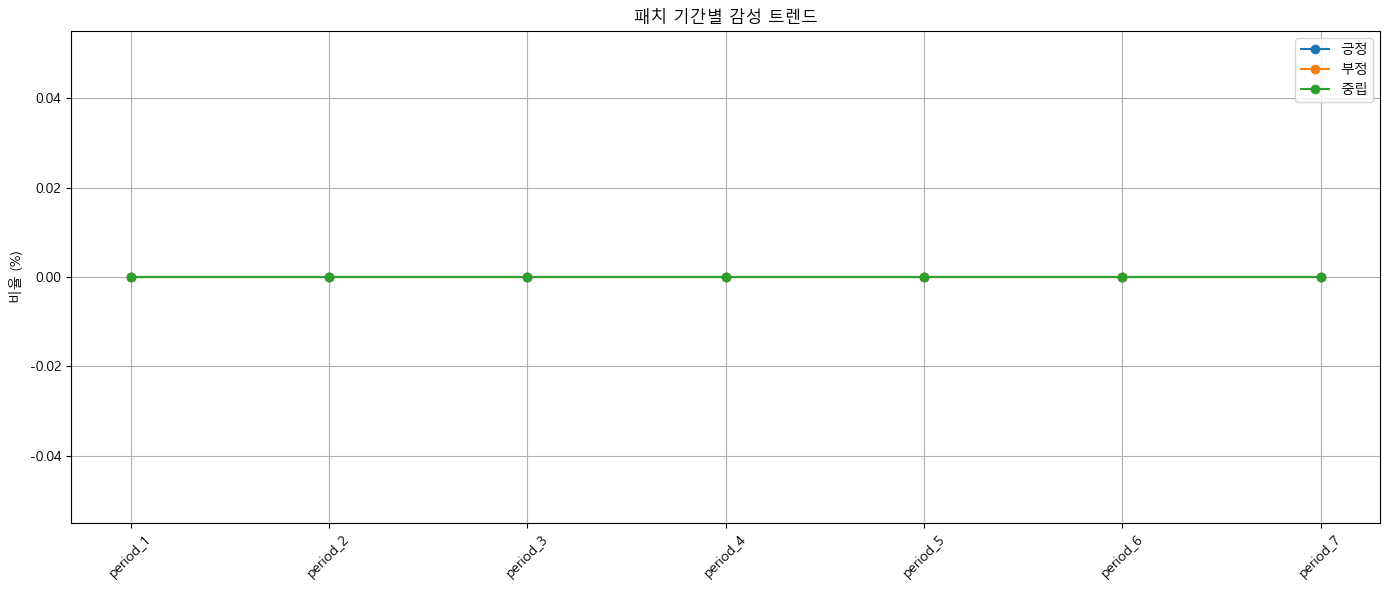

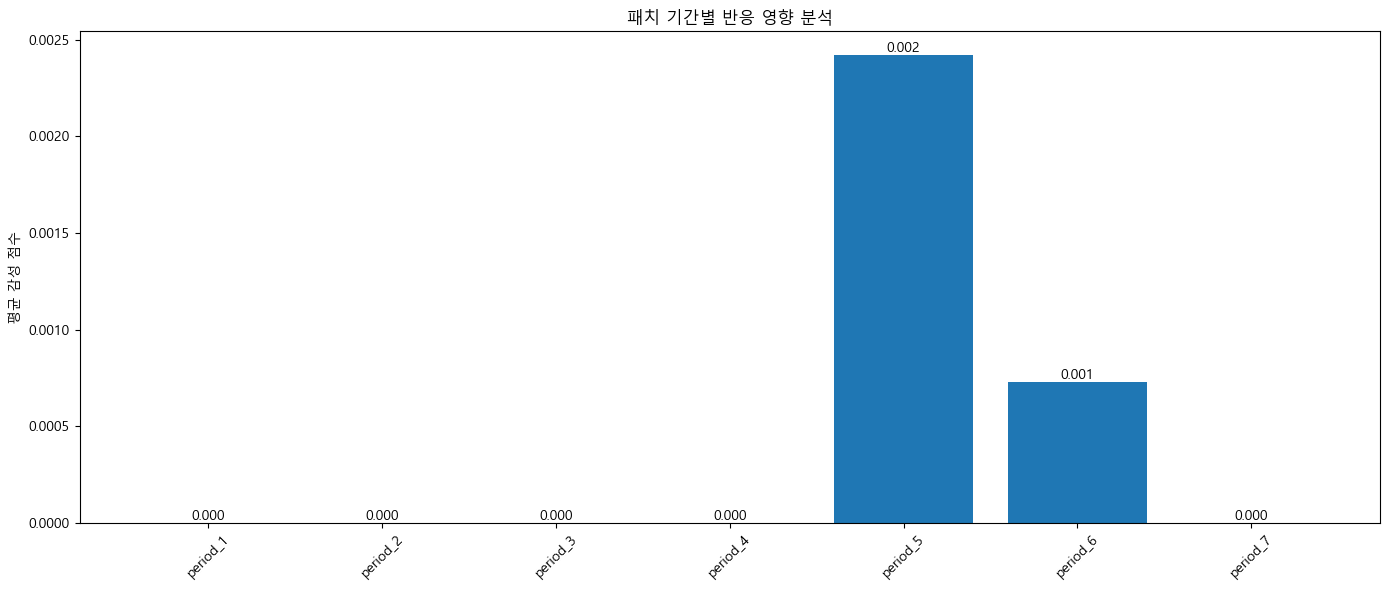

In [244]:
patch_result_df = plot_patch_analysis_auto(df_transform,patch_times)